Training Trajectory GP...
Training RHS GP G(N)...
Training Noise GP Sigma(N)...


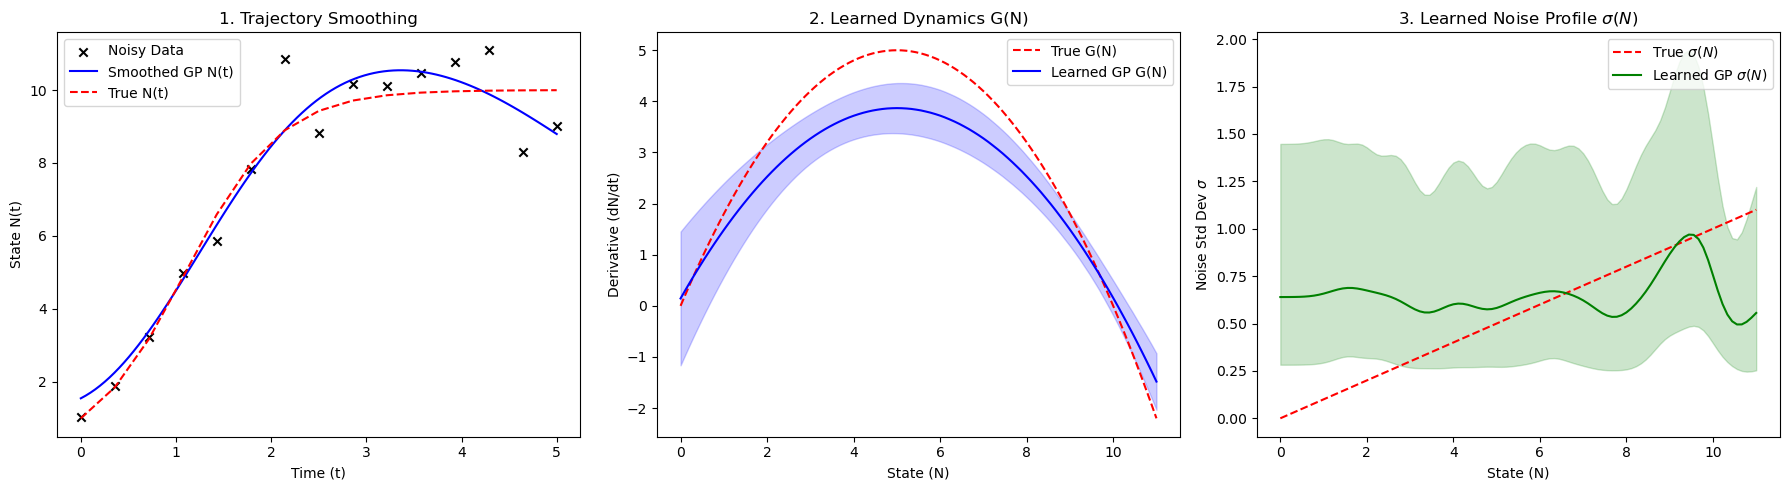

In [17]:
import torch
import gpytorch
import matplotlib.pyplot as plt

# ==========================================
# 1. Generate Synthetic Data
# ==========================================
torch.manual_seed(42)

# Time points
t = torch.linspace(0, 5, 15).view(-1, 1)

# True dynamics: Logistic growth G(N) = r*N*(1 - N/K)
r, K = 2.0, 10.0
# Exact solution for logistic growth
true_N = K / (1 + ((K - 1.0)/1.0) * torch.exp(-r * t))

# True noise: Sigma increases as N increases (Heteroscedastic)
def true_sigma(N):
    return 0.1 * N

noise_std = true_sigma(true_N)
y = true_N + torch.randn_like(true_N) * noise_std

# ==========================================
# 2. Specific GP Models & Training Helper
# ==========================================

class TrajGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(TrajGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        # Added a GammaPrior to force a stiffer lengthscale, preventing the 
        # GP from absorbing the noise by passing exactly through the points.
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(
                lengthscale_prior=gpytorch.priors.GammaPrior(3.0, 1.0)
            )
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class RHSGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(RHSGPModel, self).__init__(train_x, train_y, likelihood)
        # ZeroMean and PolynomialKernel(power=2) mathematically match 
        # the structure of logistic growth (a downward parabola starting at 0)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.PolynomialKernel(power=2)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class NoiseGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(NoiseGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def train_gp(model, likelihood, train_x, train_y, epochs=200, lr=0.1):
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    
    for i in range(epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        
    model.eval()
    likelihood.eval()

# ==========================================
# 3. Step One: Fit Trajectory GP N(t)
# ==========================================
print("Training Trajectory GP...")
traj_likelihood = gpytorch.likelihoods.GaussianLikelihood()
traj_model = TrajGPModel(t, y.squeeze(), traj_likelihood)
train_gp(traj_model, traj_likelihood, t, y.squeeze(), epochs=300)

# Evaluate smoothed N(t) and its derivative via autograd
t_eval = torch.linspace(0, 5, 100).view(-1, 1)
t_eval.requires_grad_(True)

with gpytorch.settings.fast_pred_var():
    pred_trajectory = traj_model(t_eval)
    N_mean = pred_trajectory.mean

# Compute dN/dt
dN_dt = torch.autograd.grad(N_mean.sum(), t_eval)[0].detach()
N_mean_detached = N_mean.detach()

# ==========================================
# 4. Step Two: Learn RHS Dynamics G(N)
# ==========================================
print("Training RHS GP G(N)...")
rhs_likelihood = gpytorch.likelihoods.GaussianLikelihood()
# We use the smoothed N as inputs, and dN/dt as targets
rhs_model = RHSGPModel(N_mean_detached, dN_dt.squeeze(), rhs_likelihood)
train_gp(rhs_model, rhs_likelihood, N_mean_detached, dN_dt.squeeze(), epochs=500, lr=0.05)

# ==========================================
# 5. Step Three: Learn Noise Profile Sigma(N)
# ==========================================
print("Training Noise GP Sigma(N)...")
# Calculate residuals on the original training points
with torch.no_grad():
    N_train_mean = traj_model(t).mean
    
residuals = y.squeeze() - N_train_mean

# FIX: Added + 1.2704 to account for the expected value shift of log(chi-squared)
log_sq_residuals = torch.log(residuals**2 + 1e-6) + 1.2704

noise_likelihood = gpytorch.likelihoods.GaussianLikelihood()
noise_model = NoiseGPModel(N_train_mean.unsqueeze(1), log_sq_residuals, noise_likelihood)
train_gp(noise_model, noise_likelihood, N_train_mean.unsqueeze(1), log_sq_residuals, epochs=300)

# ==========================================
# 6. Evaluate and Plot Results
# ==========================================
N_test = torch.linspace(0, 11, 100).view(-1, 1)

# Predict G(N)
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # 1. RHS Dynamics CI
    pred_G = rhs_model(N_test)
    G_mean, (G_lower, G_upper) = pred_G.mean, pred_G.confidence_region()

    # 2. Noise Profile CI
    # We get the distribution of the log-variance
    pred_log_var_dist = noise_model(N_test)
    log_var_mean = pred_log_var_dist.mean
    log_var_lower, log_var_upper = pred_log_var_dist.confidence_region()

    # Back-transform to Sigma space: sigma = sqrt(exp(log_var))
    predicted_sigma = torch.sqrt(torch.exp(log_var_mean))
    sigma_lower = torch.sqrt(torch.exp(log_var_lower))
    sigma_upper = torch.sqrt(torch.exp(log_var_upper))

# Predict Sigma(N)
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred_log_var = noise_model(N_test).mean
    # Convert log-variance back to standard deviation: sigma = sqrt(exp(log_var))
    predicted_sigma = torch.sqrt(torch.exp(pred_log_var))

# True functions for comparison
true_G = r * N_test * (1 - N_test / K)
true_sig = true_sigma(N_test)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Trajectory
axs[0].scatter(t.numpy(), y.numpy(), color='black', marker='x', label='Noisy Data')
axs[0].plot(t_eval.detach().numpy(), N_mean_detached.numpy(), color='blue', label='Smoothed GP N(t)')
axs[0].plot(t.numpy(), true_N.numpy(), 'r--', label='True N(t)')
axs[0].set_title("1. Trajectory Smoothing")
axs[0].set_xlabel("Time (t)")
axs[0].set_ylabel("State N(t)")
axs[0].legend()

# Plot 2: RHS G(N)
axs[1].plot(N_test.numpy(), true_G.numpy(), 'r--', label='True G(N)')
axs[1].plot(N_test.numpy(), G_mean.numpy(), 'blue', label='Learned GP G(N)')
axs[1].fill_between(N_test.squeeze().numpy(), G_lower.numpy(), G_upper.numpy(), alpha=0.2, color='blue')
axs[1].set_title("2. Learned Dynamics G(N)")
axs[1].set_xlabel("State (N)")
axs[1].set_ylabel("Derivative (dN/dt)")
axs[1].legend()

# Plot 3: Noise Sigma(N)
axs[2].plot(N_test.numpy(), true_sig.numpy(), 'r--', label='True $\sigma(N)$')
axs[2].plot(N_test.numpy(), predicted_sigma.numpy(), 'green', label='Learned GP $\sigma(N)$')
axs[2].fill_between(N_test.squeeze().numpy(), sigma_lower.numpy(), sigma_upper.numpy(), alpha=0.2, color='green')
axs[2].set_title("3. Learned Noise Profile $\sigma(N)$")
axs[2].set_xlabel("State (N)")
axs[2].set_ylabel("Noise Std Dev $\sigma$")
axs[2].legend()

plt.tight_layout()
plt.show()

Training Trajectory GPs for all 3 initial conditions...
Training RHS GP G(N) using all 3 ICs...
Training Noise GP Sigma(N) using all 3 ICs...


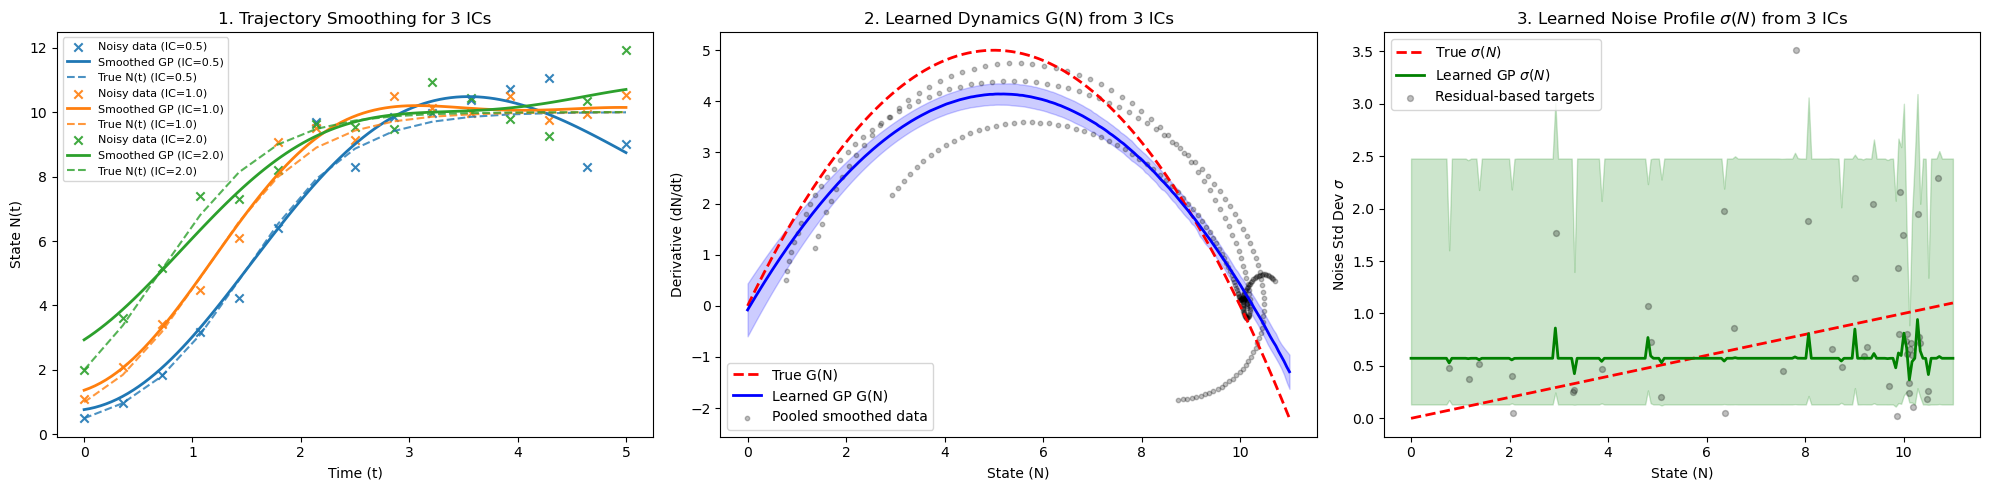

In [50]:
import torch
import gpytorch
import matplotlib.pyplot as plt

# ==========================================
# 1. Generate Synthetic Data for 3 ICs
# ==========================================
torch.manual_seed(42)

# Shared time points
t = torch.linspace(0, 5, 15).view(-1, 1)

# True dynamics: Logistic growth G(N) = r*N*(1 - N/K)
r, K = 2.0, 10.0

# Three initial conditions
initial_conditions = [0.5, 1.0, 2.0]
n_ic = len(initial_conditions)

def logistic_solution(t, N0, r, K):
    return K / (1 + ((K - N0) / N0) * torch.exp(-r * t))

def true_sigma(N):
    return 0.1 * N

# Generate one noisy trajectory per IC
true_trajectories = []
observed_trajectories = []
noise_stds = []

for N0 in initial_conditions:
    true_N = logistic_solution(t, N0, r, K)
    noise_std = true_sigma(true_N)
    y = true_N + torch.randn_like(true_N) * noise_std

    true_trajectories.append(true_N)
    observed_trajectories.append(y)
    noise_stds.append(noise_std)

# ==========================================
# 2. Specific GP Models & Training Helper
# ==========================================

class TrajGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(TrajGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(
                lengthscale_prior=gpytorch.priors.GammaPrior(3.0, 1.0)
            )
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class RHSGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(RHSGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.PolynomialKernel(power=2)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class NoiseGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(NoiseGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def train_gp(model, likelihood, train_x, train_y, epochs=200, lr=0.1):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()

    model.eval()
    likelihood.eval()


# ==========================================
# 3. Step One: Fit Trajectory GP N_i(t) for each IC
# ==========================================
print("Training Trajectory GPs for all 3 initial conditions...")

t_eval_base = torch.linspace(0, 5, 100).view(-1, 1)

traj_models = []
traj_likelihoods = []

all_N_mean = []
all_dN_dt = []

all_N_train_mean = []
all_residuals = []

for i in range(n_ic):
    y_i = observed_trajectories[i].squeeze()

    traj_likelihood = gpytorch.likelihoods.GaussianLikelihood()
    traj_model = TrajGPModel(t, y_i, traj_likelihood)
    train_gp(traj_model, traj_likelihood, t, y_i, epochs=300, lr=0.1)

    traj_models.append(traj_model)
    traj_likelihoods.append(traj_likelihood)

    # Evaluate smoothed trajectory and derivative on dense grid
    t_eval = t_eval_base.clone().detach().requires_grad_(True)

    with gpytorch.settings.fast_pred_var():
        pred_trajectory = traj_model(t_eval)
        N_mean = pred_trajectory.mean

    dN_dt = torch.autograd.grad(N_mean.sum(), t_eval)[0].detach()

    all_N_mean.append(N_mean.detach().unsqueeze(1))   # shape: [100, 1]
    all_dN_dt.append(dN_dt.detach())                  # shape: [100, 1]

    # Residuals at original training points, for noise GP
    with torch.no_grad():
        N_train_mean = traj_model(t).mean.unsqueeze(1)   # shape: [15, 1]

    residuals = observed_trajectories[i].squeeze() - N_train_mean.squeeze()

    all_N_train_mean.append(N_train_mean)
    all_residuals.append(residuals)

# Pool all ICs together for downstream learning
N_rhs_train = torch.cat(all_N_mean, dim=0)                  # [3*100, 1]
dN_rhs_train = torch.cat(all_dN_dt, dim=0).squeeze()        # [3*100]

N_noise_train = torch.cat(all_N_train_mean, dim=0)          # [3*15, 1]
residuals_all = torch.cat(all_residuals, dim=0)             # [3*15]

# ==========================================
# 4. Step Two: Learn Shared RHS Dynamics G(N)
# ==========================================
print("Training RHS GP G(N) using all 3 ICs...")

rhs_likelihood = gpytorch.likelihoods.GaussianLikelihood()
rhs_model = RHSGPModel(N_rhs_train, dN_rhs_train, rhs_likelihood)
train_gp(rhs_model, rhs_likelihood, N_rhs_train, dN_rhs_train, epochs=500, lr=0.05)

# ==========================================
# 5. Step Three: Learn Shared Noise Profile Sigma(N)
# ==========================================
print("Training Noise GP Sigma(N) using all 3 ICs...")

# E[log(Z^2)] for Z ~ N(0,1) is about -1.2704, so we add 1.2704 to debias
log_sq_residuals = torch.log(residuals_all**2 + 1e-6) + 1.2704

noise_likelihood = gpytorch.likelihoods.GaussianLikelihood()
noise_model = NoiseGPModel(N_noise_train, log_sq_residuals, noise_likelihood)
train_gp(noise_model, noise_likelihood, N_noise_train, log_sq_residuals, epochs=300, lr=0.1)

# ==========================================
# 6. Evaluate Models
# ==========================================
N_test = torch.linspace(0, 11, 200).view(-1, 1)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # RHS prediction
    pred_G = rhs_model(N_test)
    G_mean = pred_G.mean
    G_lower, G_upper = pred_G.confidence_region()

    # Noise prediction in log-variance space
    pred_log_var_dist = noise_model(N_test)
    log_var_mean = pred_log_var_dist.mean
    log_var_lower, log_var_upper = pred_log_var_dist.confidence_region()

    # Back-transform to sigma space
    predicted_sigma = torch.sqrt(torch.exp(log_var_mean))
    sigma_lower = torch.sqrt(torch.exp(log_var_lower))
    sigma_upper = torch.sqrt(torch.exp(log_var_upper))

# True comparison curves
true_G = r * N_test * (1 - N_test / K)
true_sig = true_sigma(N_test)

# ==========================================
# 7. Plot Results
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

colors = ['tab:blue', 'tab:orange', 'tab:green']

# Plot 1: Trajectory smoothing for all 3 ICs
for i, N0 in enumerate(initial_conditions):
    true_N = true_trajectories[i]
    y_i = observed_trajectories[i]

    t_eval = t_eval_base.clone()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        N_mean_i = traj_models[i](t_eval).mean

    axs[0].scatter(
        t.numpy(),
        y_i.numpy(),
        marker='x',
        color=colors[i],
        alpha=0.9,
        label=f'Noisy data (IC={N0})'
    )
    axs[0].plot(
        t_eval.numpy(),
        N_mean_i.numpy(),
        color=colors[i],
        linewidth=2,
        label=f'Smoothed GP (IC={N0})'
    )
    axs[0].plot(
        t.numpy(),
        true_N.numpy(),
        '--',
        color=colors[i],
        alpha=0.8,
        label=f'True N(t) (IC={N0})'
    )

axs[0].set_title("1. Trajectory Smoothing for 3 ICs")
axs[0].set_xlabel("Time (t)")
axs[0].set_ylabel("State N(t)")
axs[0].legend(fontsize=8)

# Plot 2: Shared RHS G(N)
axs[1].plot(N_test.numpy(), true_G.numpy(), 'r--', linewidth=2, label='True G(N)')
axs[1].plot(N_test.numpy(), G_mean.numpy(), color='blue', linewidth=2, label='Learned GP G(N)')
axs[1].fill_between(
    N_test.squeeze().numpy(),
    G_lower.numpy(),
    G_upper.numpy(),
    alpha=0.2,
    color='blue'
)
axs[1].scatter(
    N_rhs_train.numpy(),
    dN_rhs_train.numpy(),
    s=10,
    alpha=0.25,
    color='black',
    label='Pooled smoothed data'
)
axs[1].set_title("2. Learned Dynamics G(N) from 3 ICs")
axs[1].set_xlabel("State (N)")
axs[1].set_ylabel("Derivative (dN/dt)")
axs[1].legend()

# Plot 3: Shared Noise Sigma(N)
axs[2].plot(N_test.numpy(), true_sig.numpy(), 'r--', linewidth=2, label='True $\sigma(N)$')
axs[2].plot(N_test.numpy(), predicted_sigma.numpy(), color='green', linewidth=2, label='Learned GP $\sigma(N)$')
axs[2].fill_between(
    N_test.squeeze().numpy(),
    sigma_lower.numpy(),
    sigma_upper.numpy(),
    alpha=0.2,
    color='green'
)
axs[2].scatter(
    N_noise_train.numpy(),
    torch.sqrt(torch.exp(log_sq_residuals)).numpy(),
    s=18,
    alpha=0.25,
    color='black',
    label='Residual-based targets'
)
axs[2].set_title("3. Learned Noise Profile $\sigma(N)$ from 3 ICs")
axs[2].set_xlabel("State (N)")
axs[2].set_ylabel("Noise Std Dev $\sigma$")
axs[2].legend()

plt.tight_layout()
plt.show()

Training Trajectory GP...
Training RHS GP G(N)...
Training monotone Sigma(N)...
Rolling out ODE from learned RHS GP...
RMSE between trajectory GP mean and RHS rollout: 0.5364


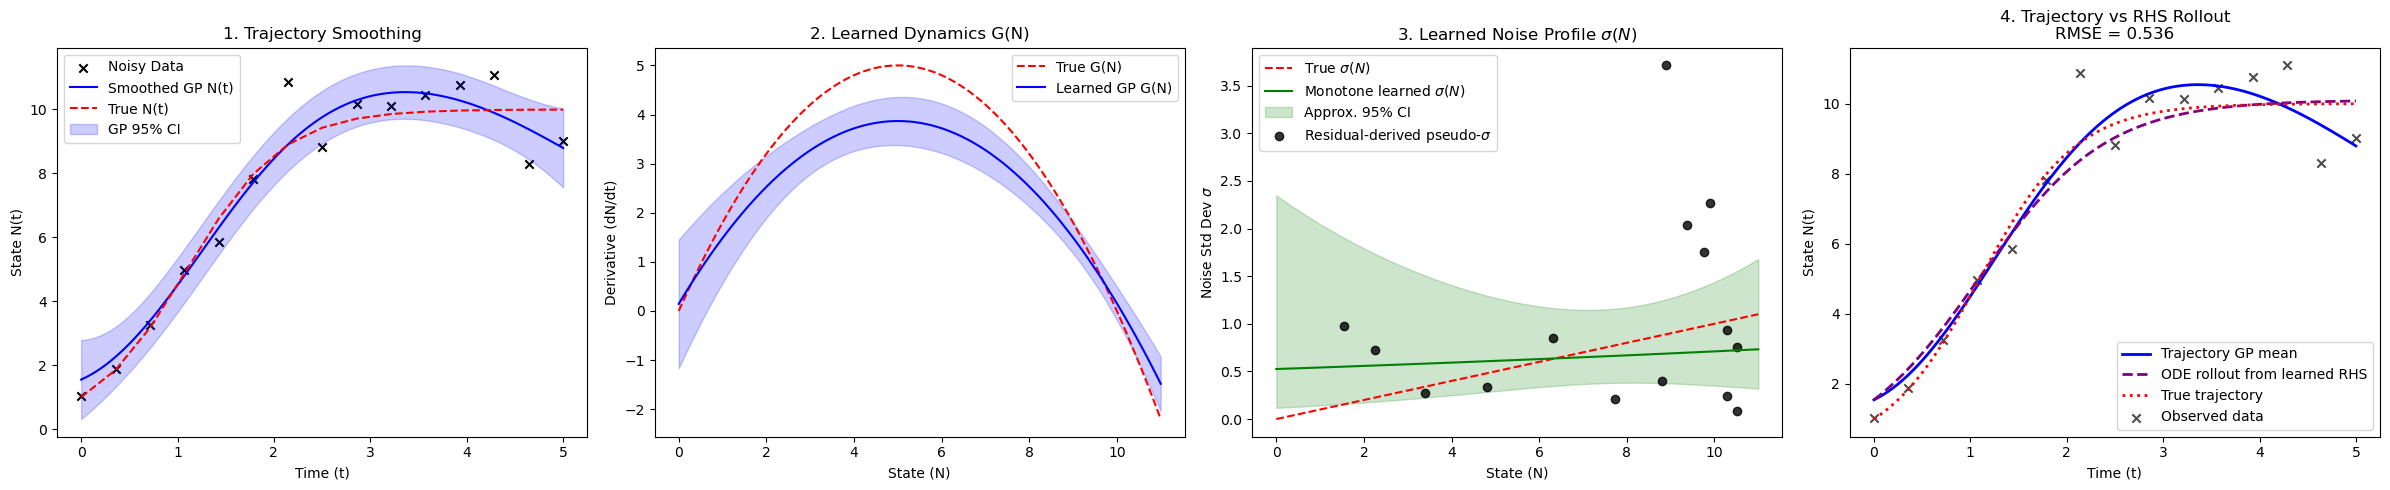

In [25]:
import torch
import gpytorch
import matplotlib.pyplot as plt

# ==========================================
# 1. Generate Synthetic Data
# ==========================================
torch.manual_seed(42)

# Time points
t = torch.linspace(0, 5, 15).view(-1, 1)

# True dynamics: Logistic growth G(N) = r*N*(1 - N/K)
r, K = 2.0, 10.0

# Exact solution for logistic growth
true_N = K / (1 + ((K - 1.0) / 1.0) * torch.exp(-r * t))

# True noise: Sigma increases as N increases (Heteroscedastic)
def true_sigma(N):
    return 0.1 * N

noise_std = true_sigma(true_N)
y = true_N + torch.randn_like(true_N) * noise_std

# ==========================================
# 2. Specific GP Models & Training Helper
# ==========================================

class TrajGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(TrajGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(
                lengthscale_prior=gpytorch.priors.GammaPrior(3.0, 1.0)
            )
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class RHSGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(RHSGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.PolynomialKernel(power=2)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def train_gp(model, likelihood, train_x, train_y, epochs=200, lr=0.1):
    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()

    model.eval()
    likelihood.eval()

# ==========================================
# 3. Step One: Fit Trajectory GP N(t)
# ==========================================
print("Training Trajectory GP...")
traj_likelihood = gpytorch.likelihoods.GaussianLikelihood()
traj_model = TrajGPModel(t, y.squeeze(), traj_likelihood)
train_gp(traj_model, traj_likelihood, t, y.squeeze(), epochs=300)

# Evaluate smoothed N(t) and its derivative via autograd
t_eval = torch.linspace(0, 5, 100).view(-1, 1)
t_eval.requires_grad_(True)

with gpytorch.settings.fast_pred_var():
    pred_trajectory = traj_model(t_eval)
    N_mean = pred_trajectory.mean
    N_lower, N_upper = pred_trajectory.confidence_region()

# Compute dN/dt from smoothed trajectory mean
dN_dt = torch.autograd.grad(N_mean.sum(), t_eval)[0].detach()
N_mean_detached = N_mean.detach()

# ==========================================
# 4. Step Two: Learn RHS Dynamics G(N)
# ==========================================
print("Training RHS GP G(N)...")
rhs_likelihood = gpytorch.likelihoods.GaussianLikelihood()
rhs_model = RHSGPModel(N_mean_detached.unsqueeze(-1), dN_dt.squeeze(), rhs_likelihood)
train_gp(
    rhs_model,
    rhs_likelihood,
    N_mean_detached.unsqueeze(-1),
    dN_dt.squeeze(),
    epochs=500,
    lr=0.05,
)

# ==========================================
# 5. Step Three: Learn Noise Profile Sigma(N)
# ==========================================
print("Training monotone Sigma(N)...")

with torch.no_grad():
    N_train_mean = traj_model(t).mean

residuals = y.squeeze() - N_train_mean
log_sq_residuals = torch.log(residuals**2 + 1e-6) + 1.2704


class MonotoneSigmaModel(torch.nn.Module):
    """
    log sigma^2(N) = bias + softplus(raw_slope) * N
    Since softplus(raw_slope) > 0, sigma(N) is monotone increasing.
    """
    def __init__(self, init_bias=-2.0, init_raw_slope=0.0):
        super().__init__()
        self.bias = torch.nn.Parameter(torch.tensor(float(init_bias)))
        self.raw_slope = torch.nn.Parameter(torch.tensor(float(init_raw_slope)))

    def forward(self, x):
        x = x.squeeze(-1)
        slope = torch.nn.functional.softplus(self.raw_slope)
        log_var = self.bias + slope * x
        sigma = torch.exp(0.5 * log_var)
        return sigma, log_var


def train_monotone_sigma_model(model, train_x, train_log_var, epochs=2000, lr=0.03):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for i in range(epochs):
        optimizer.zero_grad()
        _, pred_log_var = model(train_x)
        loss = ((pred_log_var - train_log_var) ** 2).mean()
        loss.backward()
        optimizer.step()

    model.eval()


sigma_model = MonotoneSigmaModel()
train_monotone_sigma_model(
    sigma_model,
    N_train_mean.unsqueeze(1).detach(),
    log_sq_residuals.detach(),
    epochs=2000,
    lr=0.03,
)

# ==========================================
# 6. ODE Rollout Using Learned RHS
# ==========================================
print("Rolling out ODE from learned RHS GP...")

def rhs_mean_fn(n_scalar):
    """
    Evaluate the posterior mean of G(N) at a scalar state N.
    Input/Output are scalar torch tensors.
    """
    n_in = n_scalar.view(1, 1)
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        return rhs_model(n_in).mean.squeeze()

def rk4_rollout(rhs_fn, t_grid, x0):
    """
    Deterministic RK4 rollout for dN/dt = rhs_fn(N)
    t_grid: [T, 1] or [T]
    x0: scalar tensor
    """
    t_flat = t_grid.squeeze()
    xs = [x0.clone()]

    x = x0.clone()
    for i in range(len(t_flat) - 1):
        dt = t_flat[i + 1] - t_flat[i]

        k1 = rhs_fn(x)
        k2 = rhs_fn(x + 0.5 * dt * k1)
        k3 = rhs_fn(x + 0.5 * dt * k2)
        k4 = rhs_fn(x + dt * k3)

        x = x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        xs.append(x.clone())

    return torch.stack(xs)

# Use the smoothed initial condition from the trajectory GP
N0_rollout = N_mean_detached[0]
N_rollout = rk4_rollout(rhs_mean_fn, t_eval.detach(), N0_rollout)

# Optional consistency metric
traj_rhs_rmse = torch.sqrt(torch.mean((N_rollout - N_mean_detached) ** 2))
print(f"RMSE between trajectory GP mean and RHS rollout: {traj_rhs_rmse.item():.4f}")

# ==========================================
# 7. Evaluate and Plot Results
# ==========================================
N_test = torch.linspace(0, 11, 100).view(-1, 1)

# Predict G(N)
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred_G = rhs_model(N_test)
    G_mean, (G_lower, G_upper) = pred_G.mean, pred_G.confidence_region()

# Predict Sigma(N)
with torch.no_grad():
    predicted_sigma, log_var_mean = sigma_model(N_test)

# Approximate parameter covariance for sigma regression
with torch.no_grad():
    x_train = N_train_mean.detach()
    slope = torch.nn.functional.softplus(sigma_model.raw_slope).detach()

    _, fitted_log_var_train = sigma_model(N_train_mean.unsqueeze(1))
    reg_resid = log_sq_residuals.detach() - fitted_log_var_train.detach()
    n = x_train.numel()

    X = torch.stack([torch.ones_like(x_train), x_train], dim=1)
    XtX = X.T @ X
    XtX_inv = torch.linalg.pinv(XtX)

    sigma2_hat = (reg_resid @ reg_resid) / max(n - 2, 1)
    cov_beta = sigma2_hat * XtX_inv

    var_bias = cov_beta[0, 0]
    var_slope = cov_beta[1, 1]
    cov_bias_slope = cov_beta[0, 1]

    x_test = N_test.squeeze()
    var_log_var = (
        var_bias
        + (x_test ** 2) * var_slope
        + 2.0 * x_test * cov_bias_slope
    )
    var_log_var = torch.clamp(var_log_var, min=1e-12)
    std_log_var = torch.sqrt(var_log_var)

    log_var_lower = log_var_mean - 2.0 * std_log_var
    log_var_upper = log_var_mean + 2.0 * std_log_var

    sigma_lower = torch.exp(0.5 * log_var_lower)
    sigma_upper = torch.exp(0.5 * log_var_upper)

# True functions for comparison
true_G = r * N_test * (1 - N_test / K)
true_sig = true_sigma(N_test)

# True trajectory on t_eval for comparison
true_N_eval = K / (1 + ((K - 1.0) / 1.0) * torch.exp(-r * t_eval.detach()))

# Residual-derived pseudo-sigma points
residual_sigma_points = torch.sqrt(torch.exp(log_sq_residuals.detach()))

# ==========================================
# 8. Plotting
# ==========================================
fig, axs = plt.subplots(1, 4, figsize=(24, 5))

# Plot 1: Trajectory
axs[0].scatter(t.numpy(), y.numpy(), color='black', marker='x', label='Noisy Data')
axs[0].plot(t_eval.detach().numpy(), N_mean_detached.numpy(), color='blue', label='Smoothed GP N(t)')
axs[0].plot(t.numpy(), true_N.numpy(), 'r--', label='True N(t)')
axs[0].fill_between(
    t_eval.squeeze().detach().numpy(),
    N_lower.detach().numpy(),
    N_upper.detach().numpy(),
    alpha=0.2,
    color='blue',
    label='GP 95% CI'
)
axs[0].set_title("1. Trajectory Smoothing")
axs[0].set_xlabel("Time (t)")
axs[0].set_ylabel("State N(t)")
axs[0].legend()

# Plot 2: RHS G(N)
axs[1].plot(N_test.numpy(), true_G.numpy(), 'r--', label='True G(N)')
axs[1].plot(N_test.numpy(), G_mean.numpy(), 'blue', label='Learned GP G(N)')
axs[1].fill_between(
    N_test.squeeze().numpy(),
    G_lower.numpy(),
    G_upper.numpy(),
    alpha=0.2,
    color='blue'
)
axs[1].set_title("2. Learned Dynamics G(N)")
axs[1].set_xlabel("State (N)")
axs[1].set_ylabel("Derivative (dN/dt)")
axs[1].legend()

# Plot 3: Noise Sigma(N)
axs[2].plot(N_test.numpy(), true_sig.numpy(), 'r--', label='True $\sigma(N)$')
axs[2].plot(N_test.numpy(), predicted_sigma.numpy(), 'green', label='Monotone learned $\sigma(N)$')
axs[2].fill_between(
    N_test.squeeze().numpy(),
    sigma_lower.numpy(),
    sigma_upper.numpy(),
    alpha=0.2,
    color='green',
    label='Approx. 95% CI'
)
axs[2].scatter(
    N_train_mean.detach().numpy(),
    residual_sigma_points.numpy(),
    color='black',
    marker='o',
    alpha=0.8,
    label='Residual-derived pseudo-$\sigma$'
)
axs[2].set_title("3. Learned Noise Profile $\sigma(N)$")
axs[2].set_xlabel("State (N)")
axs[2].set_ylabel("Noise Std Dev $\sigma$")
axs[2].legend()

# Plot 4: ODE rollout consistency check
axs[3].plot(
    t_eval.detach().numpy(),
    N_mean_detached.numpy(),
    color='blue',
    linewidth=2,
    label='Trajectory GP mean'
)
axs[3].plot(
    t_eval.detach().numpy(),
    N_rollout.detach().numpy(),
    color='purple',
    linestyle='--',
    linewidth=2,
    label='ODE rollout from learned RHS'
)
axs[3].plot(
    t_eval.detach().numpy(),
    true_N_eval.numpy(),
    'r:',
    linewidth=2,
    label='True trajectory'
)
axs[3].scatter(
    t.numpy(),
    y.numpy(),
    color='black',
    marker='x',
    alpha=0.7,
    label='Observed data'
)
axs[3].set_title(f"4. Trajectory vs RHS Rollout\nRMSE = {traj_rhs_rmse.item():.3f}")
axs[3].set_xlabel("Time (t)")
axs[3].set_ylabel("State N(t)")
axs[3].legend()

plt.tight_layout()
plt.show()

In [122]:
import math
import torch
import torch.nn as nn
import gpytorch
import matplotlib.pyplot as plt

# ============================================================
# Full pipeline:
#   A) Generate synthetic multi-trajectory logistic data
#   B) Pretrain from a decoupled pipeline:
#        1. Smooth each trajectory N_i(t) with a trajectory GP
#        2. Estimate dN/dt from the smoothed means
#        3. Pool (N, dN/dt) pairs across trajectories and fit an RHS GP G(N)
#        4. Fit a simple monotone model for log sigma^2(N)
#   C) Warm-start a joint ODE-constrained inducing-point GP model
#   D) Jointly refine RHS and noise via differentiable RK4 + Gaussian NLL
#   E) Plot results
# ============================================================

# ============================================================
# 0. Setup
# ============================================================
torch.manual_seed(42)
dtype = torch.float32
device = "cpu"

# ============================================================
# 1. Synthetic data
# ============================================================
t_obs = torch.linspace(0.0, 5.0, 15, dtype=dtype, device=device).view(-1, 1)

r_true = 2.0
K_true = 10.0
initial_conditions_true = [0.5, 1.0, 2.0, 0.6, 1.5]  # 5 trajectories with different ICs
n_ic = len(initial_conditions_true)

def logistic_solution(t, N0, r, K):
    return K / (1 + ((K - N0) / N0) * torch.exp(-r * t))

def true_rhs(N):
    return r_true * N * (1.0 - N / K_true)

def true_sigma(N):
    return 0.1 * N

true_trajectories = []
observed_trajectories = []
true_noise_stds = []

for N0 in initial_conditions_true:
    N_true = logistic_solution(t_obs, N0, r_true, K_true)
    sigma_true = true_sigma(N_true)
    y = N_true + sigma_true * torch.randn_like(N_true)

    true_trajectories.append(N_true)
    observed_trajectories.append(y)
    true_noise_stds.append(sigma_true)

# ============================================================
# 2. Utility functions
# ============================================================
def pairwise_sq_dists(x1, x2):
    return ((x1[:, None, :] - x2[None, :, :]) ** 2).sum(dim=-1)

def rbf_kernel(x1, x2, log_lengthscale, log_outputscale):
    ell = torch.exp(log_lengthscale)
    sf2 = torch.exp(log_outputscale)
    d2 = pairwise_sq_dists(x1, x2)
    return sf2 * torch.exp(-0.5 * d2 / (ell ** 2))

def gaussian_nll(y, mean, log_var):
    var = torch.exp(log_var)
    return 0.5 * (((y - mean) ** 2) / var + log_var + math.log(2.0 * math.pi)).sum()

# ============================================================
# 3. Stage-A pretraining models (GPyTorch)
# ============================================================
class TrajGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(
                lengthscale_prior=gpytorch.priors.GammaPrior(3.0, 1.0)
            )
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

class RHSGPModel(gpytorch.models.ExactGP):
    """
    State-space GP for G(N). Using RBF here makes transfer into the
    inducing-point RBF model more natural than a polynomial kernel.
    """
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(
                lengthscale_prior=gpytorch.priors.GammaPrior(3.0, 1.0)
            )
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_gp(model, likelihood, train_x, train_y, epochs=300, lr=0.1, verbose=False):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []
    for i in range(epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if verbose and (i % 100 == 0 or i == epochs - 1):
            print(f"  GP epoch {i:4d} | loss {loss.item():.4f}")

    model.eval()
    likelihood.eval()
    return losses

class MonotoneSigmaModel(nn.Module):
    """
    log sigma^2(N) bounded strictly between min_sigma^2 and max_sigma^2
    """
    def __init__(self, init_bias=-2.0, init_raw_slope=0.0, min_sigma=1e-3, max_sigma=2.0):
        super().__init__()
        self.bias = nn.Parameter(torch.tensor(float(init_bias), dtype=dtype))
        self.raw_slope = nn.Parameter(torch.tensor(float(init_raw_slope), dtype=dtype))
        
        # Store bounds as variance
        self.min_var = min_sigma ** 2
        self.max_var = max_sigma ** 2

    def forward(self, x):
        x = x.squeeze(-1)
        slope = torch.nn.functional.softplus(self.raw_slope)
        raw_log_var = self.bias + slope * x
        
        # Exponentiate to get raw variance, then clamp it
        var = torch.clamp(torch.exp(raw_log_var), min=self.min_var, max=self.max_var)
        
        # Re-take the log for stable NLL calculations later
        log_var = torch.log(var)
        sigma = torch.sqrt(var)
        
        return sigma, log_var

def train_monotone_sigma_model(model, train_x, train_log_var, epochs=2000, lr=0.03, verbose=False):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for i in range(epochs):
        optimizer.zero_grad()
        _, pred_log_var = model(train_x)
        loss = ((pred_log_var - train_log_var) ** 2).mean()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        if verbose and (i % 500 == 0 or i == epochs - 1):
            print(f"  Sigma epoch {i:4d} | loss {loss.item():.4f}")

    model.eval()
    return losses

# ============================================================
# 4. Stage-A pretraining:
#    fit trajectory GP for each observed trajectory
# ============================================================
print("Stage A1: training trajectory GPs...")

traj_models = []
traj_likelihoods = []
traj_train_losses = []

t_dense_pre = torch.linspace(0.0, 5.0, 100, dtype=dtype, device=device).view(-1, 1)

pooled_N = []
pooled_dNdt = []
smoothed_initial_conditions = []
traj_gp_means_at_obs = []

for i in range(n_ic):
    y_i = observed_trajectories[i].squeeze()

    likelihood_i = gpytorch.likelihoods.GaussianLikelihood()
    model_i = TrajGPModel(t_obs, y_i, likelihood_i).to(device)

    print(f"  Training trajectory GP {i+1}/{n_ic}")
    losses_i = train_gp(
        model_i,
        likelihood_i,
        t_obs,
        y_i,
        epochs=1000,
        lr=0.01,
        verbose=False,
    )

    traj_models.append(model_i)
    traj_likelihoods.append(likelihood_i)
    traj_train_losses.append(losses_i)

    # Dense smoothed trajectory and derivative
    t_eval = t_dense_pre.clone().detach().requires_grad_(True)
    with gpytorch.settings.fast_pred_var():
        pred = model_i(t_eval)
        N_mean = pred.mean
    dN_dt = torch.autograd.grad(N_mean.sum(), t_eval)[0].detach().squeeze(-1)

    pooled_N.append(N_mean.detach().unsqueeze(-1))
    pooled_dNdt.append(dN_dt.detach())

    # Smoothed initial condition for warm start
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        N0_smooth = model_i(t_obs[:1]).mean.squeeze()
    smoothed_initial_conditions.append(float(N0_smooth.item()))

    # At observed times for residual-based sigma fit
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        N_obs_mean = model_i(t_obs).mean
    traj_gp_means_at_obs.append(N_obs_mean.detach())

pooled_N = torch.cat(pooled_N, dim=0)            # [n_ic * T_dense, 1]
pooled_dNdt = torch.cat(pooled_dNdt, dim=0)      # [n_ic * T_dense]

# Sort pooled state-space data by N for better conditioning/visualization
sort_idx = torch.argsort(pooled_N.squeeze())
pooled_N = pooled_N[sort_idx]
pooled_dNdt = pooled_dNdt[sort_idx]

# ============================================================
# 5. Stage-A pretraining:
#    fit RHS GP G(N) on pooled (N, dN/dt)
# ============================================================
print("Stage A2: training pooled RHS GP G(N)...")

rhs_likelihood = gpytorch.likelihoods.GaussianLikelihood()
rhs_model = RHSGPModel(pooled_N, pooled_dNdt, rhs_likelihood).to(device)

rhs_pre_losses = train_gp(
    rhs_model,
    rhs_likelihood,
    pooled_N,
    pooled_dNdt,
    epochs=500,
    lr=0.05,
    verbose=False,
)

# ============================================================
# 6. Stage-A pretraining:
#    fit monotone sigma(N) from residual-derived pseudo-variances
# ============================================================
print("Stage A3: training monotone sigma(N)...")

residual_states = []
log_sq_residuals = []

for i in range(n_ic):
    y_i = observed_trajectories[i].squeeze()
    N_mean_obs_i = traj_gp_means_at_obs[i].squeeze()

    resid_i = y_i - N_mean_obs_i
    log_var_i = torch.log(resid_i**2 + 1e-6) + 1.2704  # bias correction heuristic

    residual_states.append(N_mean_obs_i.unsqueeze(-1))
    log_sq_residuals.append(log_var_i)

residual_states = torch.cat(residual_states, dim=0)    # [n_ic * T_obs, 1]
log_sq_residuals = torch.cat(log_sq_residuals, dim=0)  # [n_ic * T_obs]

sigma_model = MonotoneSigmaModel().to(device)
sigma_pre_losses = train_monotone_sigma_model(
    sigma_model,
    residual_states.detach(),
    log_sq_residuals.detach(),
    epochs=2000,
    lr=0.03,
    verbose=False,
)

# ============================================================
# 7. Joint ODE-constrained inducing-point GP model
# ============================================================
class InducingPointGP1D(nn.Module):
    def __init__(self, Z_init, mean_type="zero", jitter=1e-5, train_inducing_locations=False):
        super().__init__()
        Z_init = Z_init.clone().detach().view(-1, 1)

        if train_inducing_locations:
            self.Z = nn.Parameter(Z_init)
        else:
            self.register_buffer("Z", Z_init)

        m = Z_init.shape[0]
        self.u = nn.Parameter(torch.zeros(m, 1, dtype=dtype, device=device))

        self.log_lengthscale = nn.Parameter(torch.tensor(0.0, dtype=dtype, device=device))
        self.log_outputscale = nn.Parameter(torch.tensor(0.0, dtype=dtype, device=device))

        self.mean_type = mean_type
        if mean_type == "constant":
            self.mean_const = nn.Parameter(torch.tensor(0.0, dtype=dtype, device=device))
        elif mean_type == "zero":
            self.register_buffer("mean_const", torch.tensor(0.0, dtype=dtype, device=device))
        else:
            raise ValueError("mean_type must be 'zero' or 'constant'")

        self.jitter = jitter

    def mean(self, x):
        if self.mean_type == "zero":
            return torch.zeros_like(x)
        return self.mean_const.expand_as(x)

    def Kzz(self):
        K = rbf_kernel(self.Z, self.Z, self.log_lengthscale, self.log_outputscale)
        eye = torch.eye(K.shape[0], dtype=K.dtype, device=K.device)
        return K + self.jitter * eye

    def forward(self, x):
        Kzz = self.Kzz()
        Kxz = rbf_kernel(x, self.Z, self.log_lengthscale, self.log_outputscale)
        alpha = torch.linalg.solve(Kzz, self.u)
        return self.mean(x) + Kxz @ alpha

    def prior_penalty(self):
        Kzz = self.Kzz()
        alpha = torch.linalg.solve(Kzz, self.u)
        quad = 0.5 * (self.u.T @ alpha).squeeze()
        sign, logdet = torch.linalg.slogdet(Kzz)
        if sign <= 0:
            raise RuntimeError("Kzz is not positive definite.")
        return quad + 0.5 * logdet
    
class ODEGPModel(nn.Module):
    def __init__(
        self, 
        rhs_Z, 
        noise_Z, 
        state_min=0.0, 
        state_max=12.0, 
        train_inducing_locations=False, 
        min_sigma=1e-3, 
        max_sigma=2.0
    ):
        super().__init__()

        self.rhs_gp = InducingPointGP1D(
            rhs_Z,
            mean_type="zero",
            train_inducing_locations=train_inducing_locations,
        )

        self.noise_gp = InducingPointGP1D(
            noise_Z,
            mean_type="constant",
            train_inducing_locations=train_inducing_locations,
        )

        self.state_min = state_min
        self.state_max = state_max
        self.min_var = min_sigma ** 2
        self.max_var = max_sigma ** 2

    def rhs(self, N):
        return self.rhs_gp(N)

    def log_var(self, N):
        raw_log_var = self.noise_gp(N)
        # Apply the exact same clamp logic here
        var = torch.clamp(torch.exp(raw_log_var), min=self.min_var, max=self.max_var)
        return torch.log(var)

    def sigma(self, N):
        return torch.sqrt(torch.exp(self.log_var(N)))

    def gp_prior_penalty(self):
        return self.rhs_gp.prior_penalty() + self.noise_gp.prior_penalty()

def rk4_step(f, t, x, dt):
    k1 = f(t, x)
    k2 = f(t + 0.5 * dt, x + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, x + 0.5 * dt * k2)
    k4 = f(t + dt, x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def solve_ode_rk4(rhs_func, x0, t_grid):
    T = t_grid.shape[0]
    xs = [x0]
    x = x0
    for k in range(T - 1):
        t0 = t_grid[k, 0]
        t1 = t_grid[k + 1, 0]
        dt = t1 - t0
        x = rk4_step(rhs_func, t0, x, dt)
        xs.append(x)
    return torch.cat(xs, dim=0)

def monotonicity_penalty_on_rhs(model, N_grid, weight=0.0):
    if weight == 0.0:
        return torch.tensor(0.0, dtype=dtype, device=device)

    N_grid = N_grid.clone().detach().requires_grad_(True)
    G = model.rhs(N_grid)
    dG_dN = torch.autograd.grad(G.sum(), N_grid, create_graph=True)[0]
    penalty = 0.01 * (G ** 2).mean() + 0.01 * (dG_dN ** 2).mean()
    return weight * penalty

def build_loss(
    model,
    t_obs,
    observed_trajectories,
    initial_conditions,
    gp_prior_weight=1.0
):
    total_nll = torch.tensor(0.0, dtype=dtype, device=device)

    for i, N0 in enumerate(initial_conditions):
        x0 = torch.tensor([[float(N0)]], dtype=dtype, device=device)

        pred_traj = solve_ode_rk4(
            rhs_func=lambda t, x: model.rhs(x),
            x0=x0,
            t_grid=t_obs,
        )

        y = observed_trajectories[i]
        log_var = model.log_var(pred_traj)
        total_nll = total_nll + gaussian_nll(y, pred_traj, log_var)

    gp_penalty = gp_prior_weight * model.gp_prior_penalty()

    reg_grid = torch.linspace(0.0, 12.0, 100, dtype=dtype, device=device).view(-1, 1)

    return total_nll + gp_penalty, total_nll.detach(), gp_penalty.detach()

# ============================================================
# 8. Build joint model and warm-start from Stage-A models
# ============================================================
rhs_Z = torch.linspace(0.0, 11.0, 20, dtype=dtype, device=device).view(-1, 1)
noise_Z = torch.linspace(0.0, 11.0, 15, dtype=dtype, device=device).view(-1, 1)

model = ODEGPModel(
    rhs_Z=rhs_Z,
    noise_Z=noise_Z,
    state_min=0.0,
    state_max=12.0,
    train_inducing_locations=False,
).to(device)

print("Stage B: warm-starting joint inducing-point model...")

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # RHS inducing values from pretrained RHS GP posterior mean
    rhs_post = rhs_model(model.rhs_gp.Z)
    rhs_mean_init = rhs_post.mean.unsqueeze(-1)
    model.rhs_gp.u.copy_(rhs_mean_init)

    # Noise inducing values from monotone sigma model
    _, log_var_init = sigma_model(model.noise_gp.Z)
    if log_var_init.ndim == 1:
        log_var_init = log_var_init.unsqueeze(-1)
    model.noise_gp.u.copy_(log_var_init)

    # Noise constant mean from fitted sigma model on residual states
    _, fitted_log_var_train = sigma_model(residual_states)
    model.noise_gp.mean_const.fill_(fitted_log_var_train.mean())

    # Transfer/approximate kernel hyperparameters from pretrained RHS GP
    rhs_lengthscale = rhs_model.covar_module.base_kernel.lengthscale.mean().detach().clamp_min(1e-6)
    rhs_outputscale = rhs_model.covar_module.outputscale.detach().clamp_min(1e-6)

    model.rhs_gp.log_lengthscale.fill_(torch.log(rhs_lengthscale))
    model.rhs_gp.log_outputscale.fill_(torch.log(rhs_outputscale))

    # Heuristic noise kernel scales
    noise_var = log_var_init.var().clamp_min(1e-6)
    model.noise_gp.log_lengthscale.fill_(math.log(2.0))
    model.noise_gp.log_outputscale.fill_(torch.log(noise_var))

# Use smoothed ICs from trajectory GPs as rollout ICs during joint training
observed_ics = [observed_trajectories[i][0] for i in range(n_ic)]

#smoothed_initial_conditions

# ============================================================
# 9. Joint training
# ============================================================
print("Stage C: training joint GP-RHS ODE model...")

optimizer = torch.optim.Adam(model.parameters(), lr=0.008)
n_epochs = 2000
joint_loss_history = []

for epoch in range(n_epochs):
    optimizer.zero_grad()

    loss, data_nll, gp_pen = build_loss(
        model,
        t_obs=t_obs,
        observed_trajectories=observed_trajectories,
        initial_conditions=observed_ics,
        gp_prior_weight=0.1,
    )

    loss.backward()
    optimizer.step()

    joint_loss_history.append(loss.item())

    if epoch % 100 == 0 or epoch == n_epochs - 1:
        print(
            f"  Epoch {epoch:4d} | "
            f"Loss {loss.item():.3f} | "
            f"Data NLL {data_nll.item():.3f} | "
            f"GP Pen {gp_pen.item():.3f}"
        )

# ============================================================
# 10. Posterior mean evaluation
# ============================================================
N_test = torch.linspace(0.0, 11.0, 300, dtype=dtype, device=device).view(-1, 1)

with torch.no_grad():
    G_mean_joint = model.rhs(N_test)
    sigma_mean_joint = model.sigma(N_test)

true_G = true_rhs(N_test)
true_sig = true_sigma(N_test)

# Dense trajectories
t_dense = torch.linspace(0.0, 5.0, 200, dtype=dtype, device=device).view(-1, 1)
learned_trajectories = []
true_trajectories_dense = []
traj_gp_dense_means = []

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    for i, (N0_true, N0_smooth) in enumerate(zip(initial_conditions_true, observed_ics)):
        x0 = torch.tensor([[float(N0_smooth)]], dtype=dtype, device=device)

        traj_hat = solve_ode_rk4(
            rhs_func=lambda t, x: model.rhs(x),
            x0=x0,
            t_grid=t_dense,
        )
        learned_trajectories.append(traj_hat)

        traj_true = logistic_solution(t_dense, N0_true, r_true, K_true)
        true_trajectories_dense.append(traj_true)

        pred_dense_i = traj_models[i](t_dense)
        traj_gp_dense_means.append(pred_dense_i.mean.unsqueeze(-1).detach())

# ============================================================
# 11. Approximate uncertainty bands for joint inducing-point model
# ============================================================
def sample_gp_function_values(gp_module, x_eval, n_samples=200, perturb_scale=0.15):
    with torch.no_grad():
        Kzz = gp_module.Kzz()
        chol = torch.linalg.cholesky(Kzz)

        samples = []
        for _ in range(n_samples):
            eps = torch.randn_like(gp_module.u)
            u_samp = gp_module.u + chol @ eps * perturb_scale

            Kxz = rbf_kernel(
                x_eval,
                gp_module.Z,
                gp_module.log_lengthscale,
                gp_module.log_outputscale,
            )
            alpha = torch.linalg.solve(Kzz, u_samp)
            f = gp_module.mean(x_eval) + Kxz @ alpha
            samples.append(f.squeeze(-1))

        return torch.stack(samples, dim=0)

rhs_samples = sample_gp_function_values(model.rhs_gp, N_test, n_samples=200, perturb_scale=0.15)
noise_logvar_samples = sample_gp_function_values(model.noise_gp, N_test, n_samples=200, perturb_scale=0.15)
sigma_samples = torch.sqrt(torch.exp(noise_logvar_samples))

G_lower_joint = rhs_samples.quantile(0.025, dim=0)
G_upper_joint = rhs_samples.quantile(0.975, dim=0)

sigma_lower_joint = sigma_samples.quantile(0.025, dim=0)
sigma_upper_joint = sigma_samples.quantile(0.975, dim=0)

# ============================================================
# 12. Pretraining-stage evaluation for comparison
# ============================================================
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred_G_pre = rhs_model(N_test)
    G_mean_pre = pred_G_pre.mean
    G_lower_pre, G_upper_pre = pred_G_pre.confidence_region()

with torch.no_grad():
    sigma_pre, log_var_pre = sigma_model(N_test)

# Approximate sigma regression covariance
with torch.no_grad():
    x_train = residual_states.squeeze()
    X = torch.stack([torch.ones_like(x_train), x_train], dim=1)

    _, fitted_log_var_train = sigma_model(residual_states)
    reg_resid = log_sq_residuals - fitted_log_var_train.detach()

    XtX = X.T @ X
    XtX_inv = torch.linalg.pinv(XtX)

    n = x_train.numel()
    sigma2_hat = (reg_resid @ reg_resid) / max(n - 2, 1)
    cov_beta = sigma2_hat * XtX_inv

    var_bias = cov_beta[0, 0]
    var_slope = cov_beta[1, 1]
    cov_bias_slope = cov_beta[0, 1]

    x_test = N_test.squeeze()
    var_log_var = var_bias + (x_test ** 2) * var_slope + 2.0 * x_test * cov_bias_slope
    var_log_var = torch.clamp(var_log_var, min=1e-12)
    std_log_var = torch.sqrt(var_log_var)

    log_var_lower_pre = log_var_pre - 2.0 * std_log_var
    log_var_upper_pre = log_var_pre + 2.0 * std_log_var

    sigma_lower_pre = torch.exp(0.5 * log_var_lower_pre)
    sigma_upper_pre = torch.exp(0.5 * log_var_upper_pre)

# ============================================================
# 13. Plot
# ============================================================
fig, axs = plt.subplots(2, 4, figsize=(24, 10))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# (1) Pretraining trajectory smoothing
for i in range(n_ic):
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred_i = traj_models[i](t_dense)
        mean_i = pred_i.mean
        lower_i, upper_i = pred_i.confidence_region()

    axs[0, 0].scatter(
        t_obs.cpu().numpy(),
        observed_trajectories[i].squeeze().cpu().numpy(),
        marker='x',
        color=colors[i],
        alpha=0.9,
        label=f'Observed IC={initial_conditions_true[i]}'
    )
    axs[0, 0].plot(
        t_dense.cpu().numpy(),
        mean_i.cpu().numpy(),
        color=colors[i],
        linewidth=2,
        label=f'Traj GP mean IC={initial_conditions_true[i]}'
    )
    axs[0, 0].fill_between(
        t_dense.squeeze().cpu().numpy(),
        lower_i.cpu().numpy(),
        upper_i.cpu().numpy(),
        color=colors[i],
        alpha=0.12
    )
    axs[0, 0].plot(
        t_dense.cpu().numpy(),
        true_trajectories_dense[i].cpu().numpy(),
        '--',
        color=colors[i],
        alpha=0.7
    )

axs[0, 0].set_title("A1. Trajectory GP smoothing")
axs[0, 0].set_xlabel("Time t")
axs[0, 0].set_ylabel("State N(t)")
axs[0, 0].legend(fontsize=8)

# (2) Pretrained RHS GP
axs[0, 1].plot(N_test.cpu().numpy(), true_G.cpu().numpy(), 'r--', linewidth=2, label='True G(N)')
axs[0, 1].plot(N_test.cpu().numpy(), G_mean_pre.cpu().numpy(), color='blue', linewidth=2, label='Pretrained RHS GP')
axs[0, 1].fill_between(
    N_test.squeeze().cpu().numpy(),
    G_lower_pre.cpu().numpy(),
    G_upper_pre.cpu().numpy(),
    color='blue',
    alpha=0.2
)
axs[0, 1].scatter(
    pooled_N.squeeze().cpu().numpy(),
    pooled_dNdt.cpu().numpy(),
    color='black',
    s=8,
    alpha=0.3,
    label='Pooled (N, dN/dt)'
)
axs[0, 1].set_title("A2. Pooled RHS GP pretraining")
axs[0, 1].set_xlabel("State N")
axs[0, 1].set_ylabel("dN/dt")
axs[0, 1].legend(fontsize=8)

# (3) Pretrained sigma model
axs[0, 2].plot(N_test.cpu().numpy(), true_sig.cpu().numpy(), 'r--', linewidth=2, label='True sigma(N)')
axs[0, 2].plot(N_test.cpu().numpy(), sigma_pre.cpu().numpy(), color='green', linewidth=2, label='Pretrained sigma(N)')
axs[0, 2].fill_between(
    N_test.squeeze().cpu().numpy(),
    sigma_lower_pre.cpu().numpy(),
    sigma_upper_pre.cpu().numpy(),
    color='green',
    alpha=0.2
)
axs[0, 2].scatter(
    residual_states.squeeze().cpu().numpy(),
    torch.sqrt(torch.exp(log_sq_residuals)).cpu().numpy(),
    color='black',
    s=20,
    alpha=0.6,
    label='Residual pseudo-sigma'
)
axs[0, 2].set_title("A3. Monotone sigma pretraining")
axs[0, 2].set_xlabel("State N")
axs[0, 2].set_ylabel("sigma(N)")
axs[0, 2].legend(fontsize=8)

# (4) Joint training loss
axs[0, 3].plot(joint_loss_history[400:], linewidth=2)
axs[0, 3].set_title("C. Joint training loss")
axs[0, 3].set_xlabel("Epoch")
axs[0, 3].set_ylabel("Objective")

# (5) Final joint ODE trajectory fit
for i, N0 in enumerate(initial_conditions_true):
    axs[1, 0].scatter(
        t_obs.cpu().numpy(),
        observed_trajectories[i].cpu().numpy(),
        marker='x',
        color=colors[i],
        alpha=0.9,
        label=f'Observed (IC={N0})'
    )
    axs[1, 0].plot(
        t_dense.cpu().numpy(),
        true_trajectories_dense[i].cpu().numpy(),
        '--',
        color=colors[i],
        linewidth=2,
        alpha=0.8,
        label=f'True (IC={N0})'
    )
    axs[1, 0].plot(
        t_dense.cpu().numpy(),
        learned_trajectories[i].cpu().numpy(),
        color=colors[i],
        linewidth=2,
        label=f'Joint ODE (IC={N0})'
    )

axs[1, 0].set_title("Final joint ODE-constrained fit")
axs[1, 0].set_xlabel("Time t")
axs[1, 0].set_ylabel("State N(t)")
axs[1, 0].legend(fontsize=8)

# (6) Final learned RHS G(N)
axs[1, 1].plot(N_test.cpu().numpy(), true_G.cpu().numpy(), 'r--', linewidth=2, label='True G(N)')
axs[1, 1].plot(N_test.cpu().numpy(), G_mean_joint.cpu().numpy(), color='blue', linewidth=2, label='Joint GP RHS')
axs[1, 1].fill_between(
    N_test.squeeze().cpu().numpy(),
    G_lower_joint.cpu().numpy(),
    G_upper_joint.cpu().numpy(),
    color='blue',
    alpha=0.2
)
axs[1, 1].set_title("Final RHS after joint refinement")
axs[1, 1].set_xlabel("State N")
axs[1, 1].set_ylabel("dN/dt")
axs[1, 1].legend(fontsize=8)

# (7) Final learned noise sigma(N)
axs[1, 2].plot(N_test.cpu().numpy(), true_sig.cpu().numpy(), 'r--', linewidth=2, label='True sigma(N)')
axs[1, 2].plot(N_test.cpu().numpy(), sigma_mean_joint.cpu().numpy(), color='green', linewidth=2, label='Joint sigma(N)')
axs[1, 2].fill_between(
    N_test.squeeze().cpu().numpy(),
    sigma_lower_joint.cpu().numpy(),
    sigma_upper_joint.cpu().numpy(),
    color='green',
    alpha=0.2
)
axs[1, 2].set_title("Final noise after joint refinement")
axs[1, 2].set_xlabel("State N")
axs[1, 2].set_ylabel("sigma(N)")
axs[1, 2].legend(fontsize=8)

# (8) Compare pretrained smoother vs final ODE rollout
for i in range(n_ic):
    axs[1, 3].plot(
        t_dense.cpu().numpy(),
        traj_gp_dense_means[i].cpu().numpy(),
        color=colors[i],
        linewidth=2,
        alpha=0.8,
        label=f'Traj GP mean IC={initial_conditions_true[i]}'
    )
    axs[1, 3].plot(
        t_dense.cpu().numpy(),
        learned_trajectories[i].cpu().numpy(),
        '--',
        color=colors[i],
        linewidth=2,
        label=f'Joint ODE IC={initial_conditions_true[i]}'
    )

axs[1, 3].set_title("Pretraining smoother vs joint ODE")
axs[1, 3].set_xlabel("Time t")
axs[1, 3].set_ylabel("State N(t)")
axs[1, 3].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# 14. Summary printout
# ============================================================
print("\nSummary")
print("-------")
print("True ICs:             ", initial_conditions_true)
print("Smoothed IC warmstart:", [round(v.item(), 4) for v in observed_ics])

with torch.no_grad():
    rmse_list = []
    for i in range(n_ic):
        rmse_i = torch.sqrt(torch.mean((learned_trajectories[i] - true_trajectories_dense[i]) ** 2))
        rmse_list.append(rmse_i.item())

print("Final dense trajectory RMSEs against true trajectories:")
for i, val in enumerate(rmse_list):
    print(f"  IC={initial_conditions_true[i]} -> RMSE={val:.4f}")

Stage A1: training trajectory GPs...
  Training trajectory GP 1/5
  Training trajectory GP 2/5
  Training trajectory GP 3/5
  Training trajectory GP 4/5
  Training trajectory GP 5/5
Stage A2: training pooled RHS GP G(N)...
Stage A3: training monotone sigma(N)...
Stage B: warm-starting joint inducing-point model...
Stage C: training joint GP-RHS ODE model...
  Epoch    0 | Loss 181.884 | Data NLL 181.504 | GP Pen 0.380
  Epoch  100 | Loss 92.332 | Data NLL 104.335 | GP Pen -12.002
  Epoch  200 | Loss 83.492 | Data NLL 96.445 | GP Pen -12.953
  Epoch  300 | Loss 79.688 | Data NLL 92.851 | GP Pen -13.164
  Epoch  400 | Loss 77.870 | Data NLL 91.030 | GP Pen -13.159
  Epoch  500 | Loss 76.366 | Data NLL 89.434 | GP Pen -13.068
  Epoch  600 | Loss 74.308 | Data NLL 87.604 | GP Pen -13.296
  Epoch  700 | Loss 72.438 | Data NLL 85.079 | GP Pen -12.641
  Epoch  800 | Loss 69.554 | Data NLL 81.708 | GP Pen -12.154
  Epoch  900 | Loss 65.558 | Data NLL 77.689 | GP Pen -12.131


RuntimeError: Kzz is not positive definite.

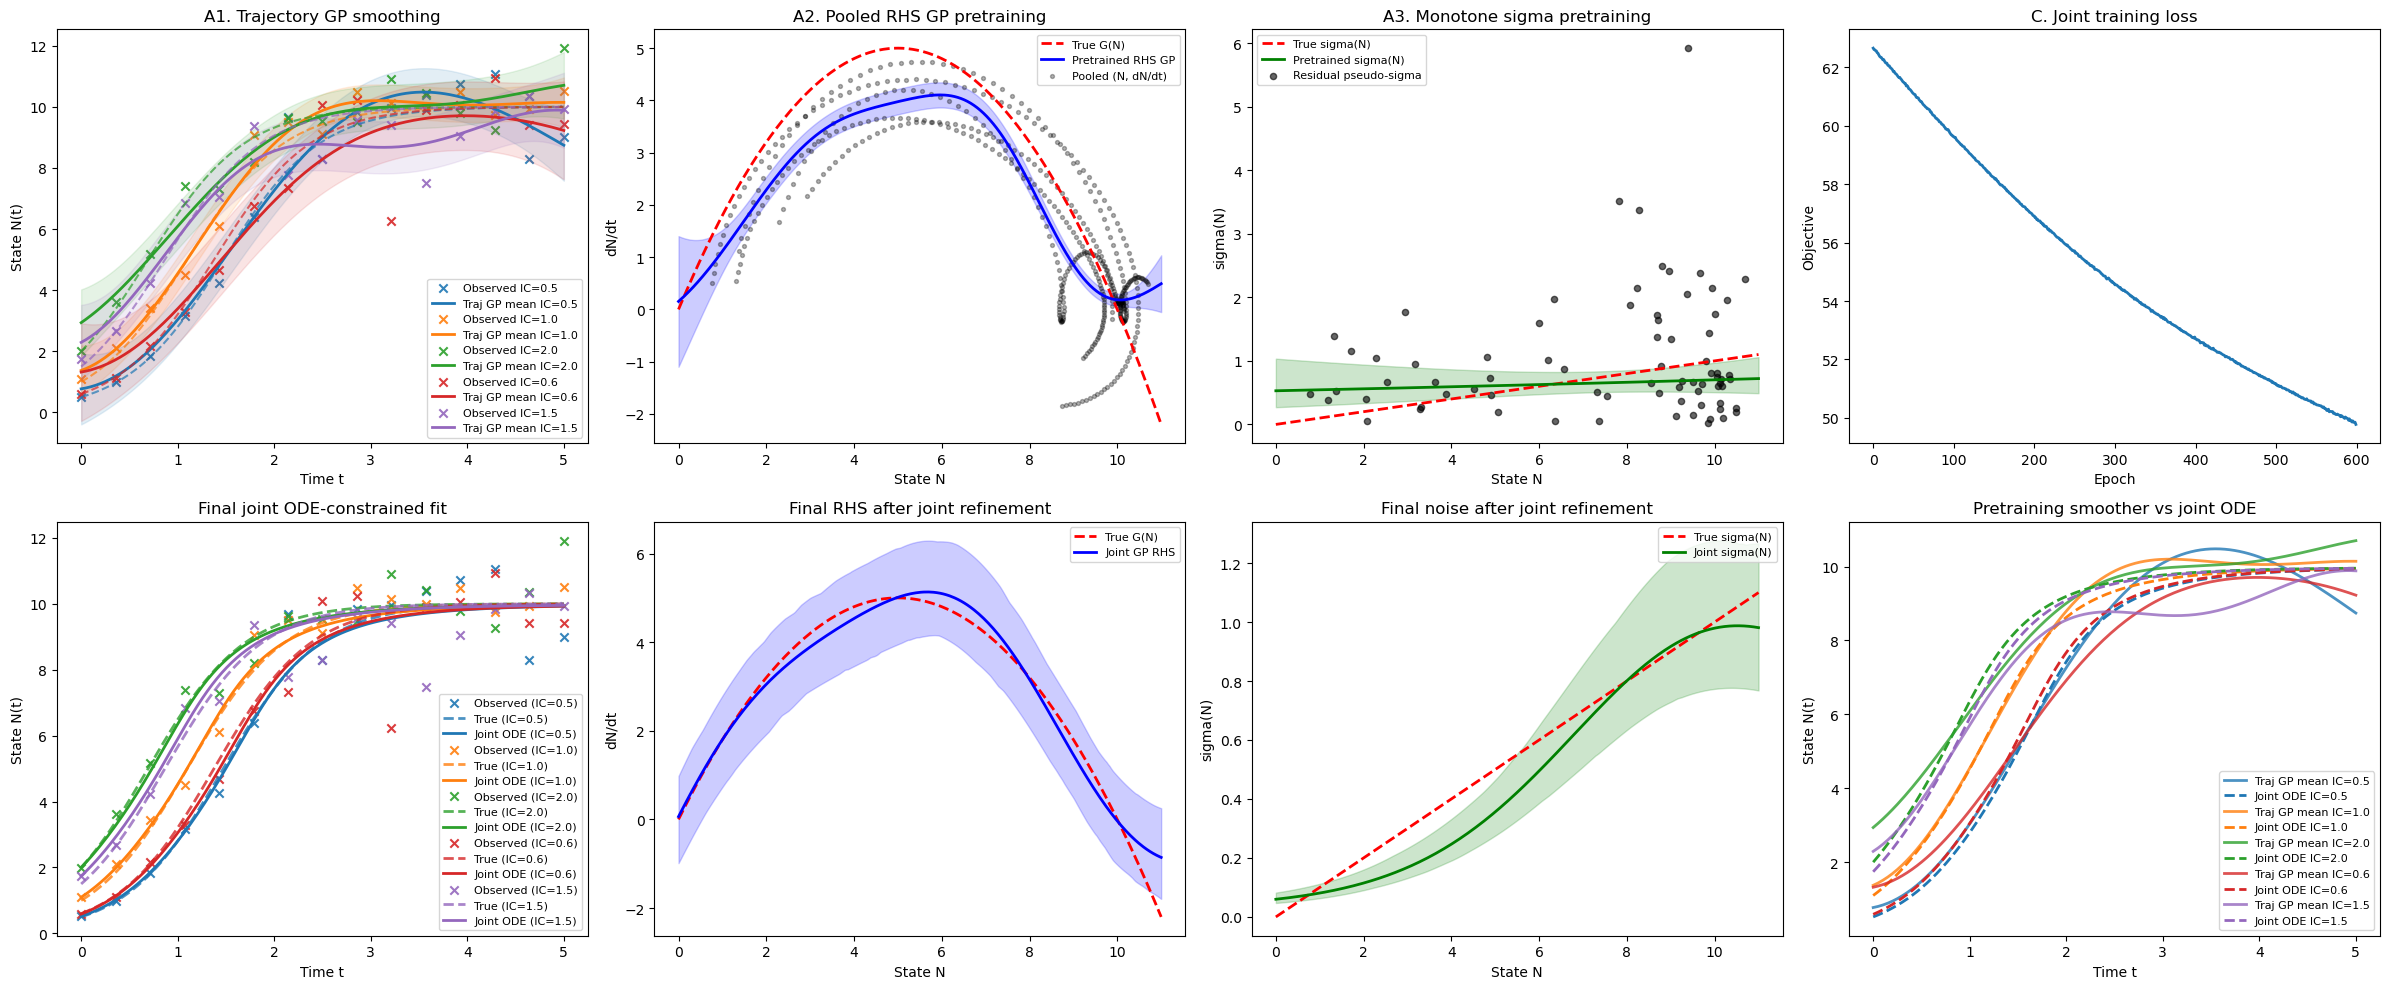


Summary
-------
True ICs:              [0.5, 1.0, 2.0, 0.6, 1.5]
Smoothed IC warmstart: [0.5168, 1.0958, 1.9983, 0.5865, 1.7397]
Final dense trajectory RMSEs against true trajectories:
  IC=0.5 -> RMSE=0.0893
  IC=1.0 -> RMSE=0.0924
  IC=2.0 -> RMSE=0.1102
  IC=0.6 -> RMSE=0.1395
  IC=1.5 -> RMSE=0.1620


In [120]:

# ============================================================
# 13. Plot
# ============================================================
fig, axs = plt.subplots(2, 4, figsize=(24, 10))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# (1) Pretraining trajectory smoothing
for i in range(n_ic):
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred_i = traj_models[i](t_dense)
        mean_i = pred_i.mean
        lower_i, upper_i = pred_i.confidence_region()

    axs[0, 0].scatter(
        t_obs.cpu().numpy(),
        observed_trajectories[i].squeeze().cpu().numpy(),
        marker='x',
        color=colors[i],
        alpha=0.9,
        label=f'Observed IC={initial_conditions_true[i]}'
    )
    axs[0, 0].plot(
        t_dense.cpu().numpy(),
        mean_i.cpu().numpy(),
        color=colors[i],
        linewidth=2,
        label=f'Traj GP mean IC={initial_conditions_true[i]}'
    )
    axs[0, 0].fill_between(
        t_dense.squeeze().cpu().numpy(),
        lower_i.cpu().numpy(),
        upper_i.cpu().numpy(),
        color=colors[i],
        alpha=0.12
    )
    axs[0, 0].plot(
        t_dense.cpu().numpy(),
        true_trajectories_dense[i].cpu().numpy(),
        '--',
        color=colors[i],
        alpha=0.7
    )

axs[0, 0].set_title("A1. Trajectory GP smoothing")
axs[0, 0].set_xlabel("Time t")
axs[0, 0].set_ylabel("State N(t)")
axs[0, 0].legend(fontsize=8)

# (2) Pretrained RHS GP
axs[0, 1].plot(N_test.cpu().numpy(), true_G.cpu().numpy(), 'r--', linewidth=2, label='True G(N)')
axs[0, 1].plot(N_test.cpu().numpy(), G_mean_pre.cpu().numpy(), color='blue', linewidth=2, label='Pretrained RHS GP')
axs[0, 1].fill_between(
    N_test.squeeze().cpu().numpy(),
    G_lower_pre.cpu().numpy(),
    G_upper_pre.cpu().numpy(),
    color='blue',
    alpha=0.2
)
axs[0, 1].scatter(
    pooled_N.squeeze().cpu().numpy(),
    pooled_dNdt.cpu().numpy(),
    color='black',
    s=8,
    alpha=0.3,
    label='Pooled (N, dN/dt)'
)
axs[0, 1].set_title("A2. Pooled RHS GP pretraining")
axs[0, 1].set_xlabel("State N")
axs[0, 1].set_ylabel("dN/dt")
axs[0, 1].legend(fontsize=8)

# (3) Pretrained sigma model
axs[0, 2].plot(N_test.cpu().numpy(), true_sig.cpu().numpy(), 'r--', linewidth=2, label='True sigma(N)')
axs[0, 2].plot(N_test.cpu().numpy(), sigma_pre.cpu().numpy(), color='green', linewidth=2, label='Pretrained sigma(N)')
axs[0, 2].fill_between(
    N_test.squeeze().cpu().numpy(),
    sigma_lower_pre.cpu().numpy(),
    sigma_upper_pre.cpu().numpy(),
    color='green',
    alpha=0.2
)
axs[0, 2].scatter(
    residual_states.squeeze().cpu().numpy(),
    torch.sqrt(torch.exp(log_sq_residuals)).cpu().numpy(),
    color='black',
    s=20,
    alpha=0.6,
    label='Residual pseudo-sigma'
)
axs[0, 2].set_title("A3. Monotone sigma pretraining")
axs[0, 2].set_xlabel("State N")
axs[0, 2].set_ylabel("sigma(N)")
axs[0, 2].legend(fontsize=8)

# (4) Joint training loss
axs[0, 3].plot(joint_loss_history[400:], linewidth=2)
axs[0, 3].set_title("C. Joint training loss")
axs[0, 3].set_xlabel("Epoch")
axs[0, 3].set_ylabel("Objective")

# (5) Final joint ODE trajectory fit
for i, N0 in enumerate(initial_conditions_true):
    axs[1, 0].scatter(
        t_obs.cpu().numpy(),
        observed_trajectories[i].cpu().numpy(),
        marker='x',
        color=colors[i],
        alpha=0.9,
        label=f'Observed (IC={N0})'
    )
    axs[1, 0].plot(
        t_dense.cpu().numpy(),
        true_trajectories_dense[i].cpu().numpy(),
        '--',
        color=colors[i],
        linewidth=2,
        alpha=0.8,
        label=f'True (IC={N0})'
    )
    axs[1, 0].plot(
        t_dense.cpu().numpy(),
        learned_trajectories[i].cpu().numpy(),
        color=colors[i],
        linewidth=2,
        label=f'Joint ODE (IC={N0})'
    )

axs[1, 0].set_title("Final joint ODE-constrained fit")
axs[1, 0].set_xlabel("Time t")
axs[1, 0].set_ylabel("State N(t)")
axs[1, 0].legend(fontsize=8)

# (6) Final learned RHS G(N)
axs[1, 1].plot(N_test.cpu().numpy(), true_G.cpu().numpy(), 'r--', linewidth=2, label='True G(N)')
axs[1, 1].plot(N_test.cpu().numpy(), G_mean_joint.cpu().numpy(), color='blue', linewidth=2, label='Joint GP RHS')
axs[1, 1].fill_between(
    N_test.squeeze().cpu().numpy(),
    G_lower_joint.cpu().numpy(),
    G_upper_joint.cpu().numpy(),
    color='blue',
    alpha=0.2
)
axs[1, 1].set_title("Final RHS after joint refinement")
axs[1, 1].set_xlabel("State N")
axs[1, 1].set_ylabel("dN/dt")
axs[1, 1].legend(fontsize=8)

# (7) Final learned noise sigma(N)
axs[1, 2].plot(N_test.cpu().numpy(), true_sig.cpu().numpy(), 'r--', linewidth=2, label='True sigma(N)')
axs[1, 2].plot(N_test.cpu().numpy(), sigma_mean_joint.cpu().numpy(), color='green', linewidth=2, label='Joint sigma(N)')
axs[1, 2].fill_between(
    N_test.squeeze().cpu().numpy(),
    sigma_lower_joint.cpu().numpy(),
    sigma_upper_joint.cpu().numpy(),
    color='green',
    alpha=0.2
)
axs[1, 2].set_title("Final noise after joint refinement")
axs[1, 2].set_xlabel("State N")
axs[1, 2].set_ylabel("sigma(N)")
axs[1, 2].legend(fontsize=8)

# (8) Compare pretrained smoother vs final ODE rollout
for i in range(n_ic):
    axs[1, 3].plot(
        t_dense.cpu().numpy(),
        traj_gp_dense_means[i].cpu().numpy(),
        color=colors[i],
        linewidth=2,
        alpha=0.8,
        label=f'Traj GP mean IC={initial_conditions_true[i]}'
    )
    axs[1, 3].plot(
        t_dense.cpu().numpy(),
        learned_trajectories[i].cpu().numpy(),
        '--',
        color=colors[i],
        linewidth=2,
        label=f'Joint ODE IC={initial_conditions_true[i]}'
    )

axs[1, 3].set_title("Pretraining smoother vs joint ODE")
axs[1, 3].set_xlabel("Time t")
axs[1, 3].set_ylabel("State N(t)")
axs[1, 3].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# 14. Summary printout
# ============================================================
print("\nSummary")
print("-------")
print("True ICs:             ", initial_conditions_true)
print("Smoothed IC warmstart:", [round(v.item(), 4) for v in observed_ics])

with torch.no_grad():
    rmse_list = []
    for i in range(n_ic):
        rmse_i = torch.sqrt(torch.mean((learned_trajectories[i] - true_trajectories_dense[i]) ** 2))
        rmse_list.append(rmse_i.item())

print("Final dense trajectory RMSEs against true trajectories:")
for i, val in enumerate(rmse_list):
    print(f"  IC={initial_conditions_true[i]} -> RMSE={val:.4f}")

Training trajectory GP...
[Traj GP] epoch=   1 loss=10.65049
[Traj GP] epoch= 100 loss=2.16862
[Traj GP] epoch= 200 loss=1.99781
[Traj GP] epoch= 300 loss=1.95693
Training monotone sigma(N)...
[Sigma]   epoch=   1 loss=24.81433
[Sigma]   epoch= 500 loss=4.13800
[Sigma]   epoch=1000 loss=4.05386
[Sigma]   epoch=1500 loss=4.03933
[Sigma]   epoch=2000 loss=4.03564
[Sigma]   epoch=2500 loss=4.03457
Training RHS by ODE rollout against observations...
[RHS]     epoch=   1 loss=76.022125 obs_nll=75.546196 cons=47.592594 curv=0.000000
[RHS]     epoch= 100 loss=1.931375 obs_nll=1.917917 cons=1.345155 curv=0.239651
[RHS]     epoch= 200 loss=0.540620 obs_nll=0.537755 cons=0.285104 curv=0.778616
[RHS]     epoch= 300 loss=0.409733 obs_nll=0.407677 cons=0.203777 curv=1.120296
[RHS]     epoch= 400 loss=0.350796 obs_nll=0.349023 cons=0.175099 curv=1.464478
[RHS]     epoch= 500 loss=0.320814 obs_nll=0.319118 cons=0.166882 curv=1.801649
[RHS]     epoch= 600 loss=0.303793 obs_nll=0.302101 cons=0.166217 c

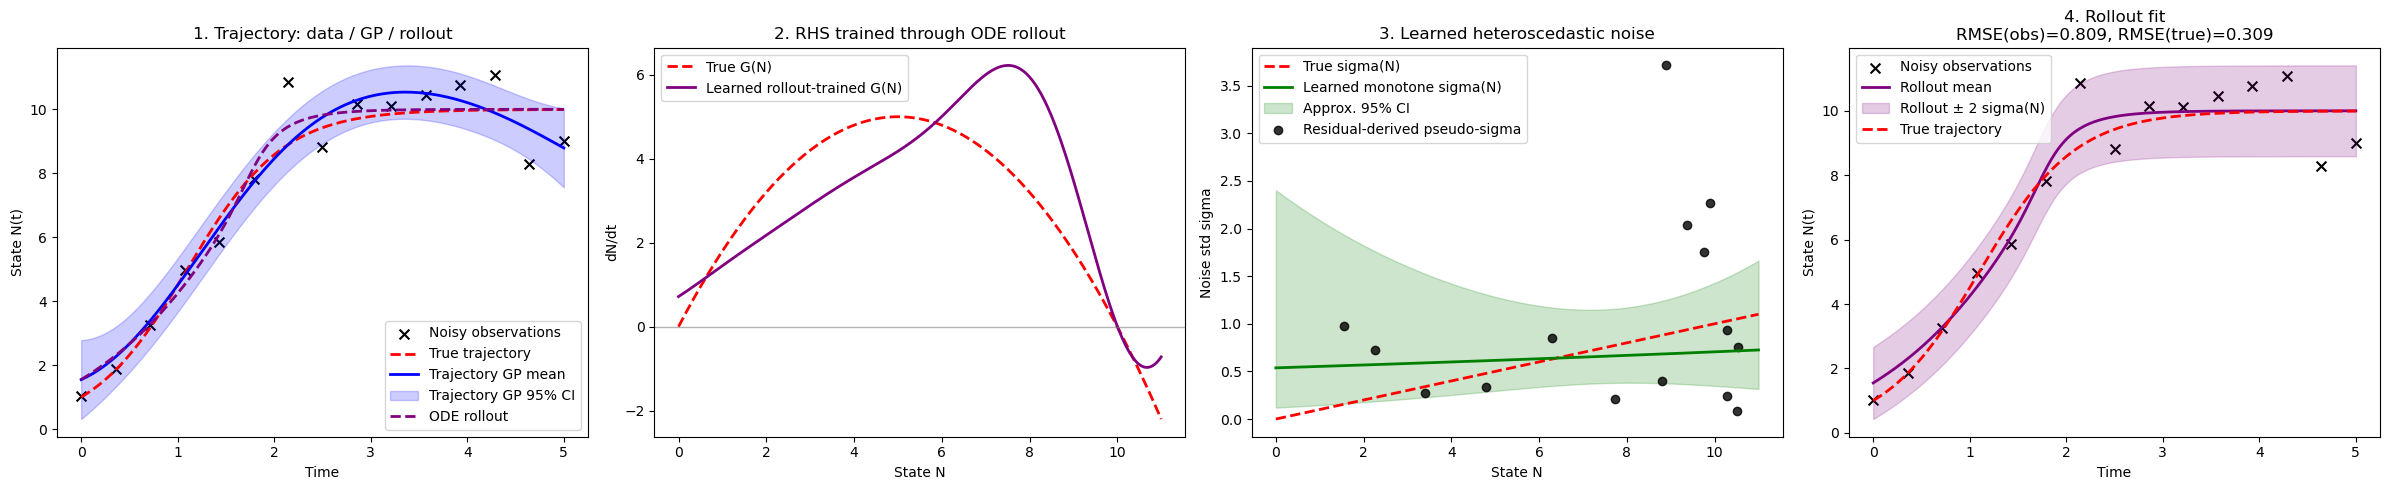

In [ ]:
import torch
import gpytorch
import matplotlib.pyplot as plt

# =========================================================
# 1. Synthetic data
# =========================================================
torch.manual_seed(42)

device = torch.device("cpu")
dtype = torch.float32

# Observation times
t_obs = torch.linspace(0, 5, 15, device=device, dtype=dtype).view(-1, 1)

# True logistic dynamics
r_true, K_true = 2.0, 10.0
N0_true = 1.0

def logistic_solution(t, r=r_true, K=K_true, N0=N0_true):
    return K / (1 + ((K - N0) / N0) * torch.exp(-r * t))

def true_rhs(N):
    return r_true * N * (1.0 - N / K_true)

def true_sigma(N):
    return 0.1 * N

N_true_obs = logistic_solution(t_obs)
noise_std = true_sigma(N_true_obs)
y_obs = N_true_obs + torch.randn_like(N_true_obs) * noise_std

# Dense grid for diagnostics / plotting
t_dense = torch.linspace(0, 5, 200, device=device, dtype=dtype).view(-1, 1)
N_true_dense = logistic_solution(t_dense)

# =========================================================
# 2. Trajectory GP for initialization / smoothing
# =========================================================
class TrajGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(
                lengthscale_prior=gpytorch.priors.GammaPrior(3.0, 1.0)
            )
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def train_exact_gp(model, likelihood, train_x, train_y, epochs=300, lr=0.1):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(epochs):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0 or i == 0:
            print(f"[Traj GP] epoch={i+1:4d} loss={loss.item():.5f}")

    model.eval()
    likelihood.eval()

print("Training trajectory GP...")
traj_likelihood = gpytorch.likelihoods.GaussianLikelihood()
traj_model = TrajGPModel(t_obs, y_obs.squeeze(), traj_likelihood).to(device)
train_exact_gp(traj_model, traj_likelihood, t_obs, y_obs.squeeze(), epochs=300, lr=0.1)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred_dense = traj_model(t_dense)
    N_gp_dense = pred_dense.mean
    N_gp_lower, N_gp_upper = pred_dense.confidence_region()

    pred_obs = traj_model(t_obs)
    N_gp_obs = pred_obs.mean

# =========================================================
# 3. Monotone sigma(N) model from residuals
# =========================================================
# Debiased log-squared residual target:
# E[log(e^2)] = log(sigma^2) - 1.2704 for e ~ N(0, sigma^2)
residuals = y_obs.squeeze() - N_gp_obs
log_sq_residuals = torch.log(residuals**2 + 1e-6) + 1.2704

class MonotoneSigmaModel(nn.Module):
    """
    log sigma^2(N) smoothly bounded below by min_sigma^2
    """
    def __init__(self, init_bias=-2.0, init_raw_slope=0.0, min_sigma=1e-3):
        super().__init__()
        self.bias = nn.Parameter(torch.tensor(float(init_bias), dtype=dtype))
        self.raw_slope = nn.Parameter(torch.tensor(float(init_raw_slope), dtype=dtype))
        self.min_var = min_sigma ** 2

    def forward(self, x):
        x = x.squeeze(-1)
        slope = torch.nn.functional.softplus(self.raw_slope)
        raw_log_var = self.bias + slope * x
        
        # Smoothly enforce minimum variance
        var = torch.exp(raw_log_var) + self.min_var
        log_var = torch.log(var)
        sigma = torch.sqrt(var)
        
        return sigma, log_var

def train_monotone_sigma_model(model, train_x, train_log_var, epochs=2500, lr=0.03):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for i in range(epochs):
        optimizer.zero_grad()
        _, pred_log_var = model(train_x)
        loss = ((pred_log_var - train_log_var) ** 2).mean()
        loss.backward()
        optimizer.step()

        if (i + 1) % 500 == 0 or i == 0:
            print(f"[Sigma]   epoch={i+1:4d} loss={loss.item():.5f}")

    model.eval()

print("Training monotone sigma(N)...")
sigma_model = MonotoneSigmaModel()
train_monotone_sigma_model(
    sigma_model,
    N_gp_obs.detach().unsqueeze(1),
    log_sq_residuals.detach(),
    epochs=2500,
    lr=0.03,
)

# =========================================================
# 4. Differentiable RHS model G(N)
#    Rollout-trained directly against observations
# =========================================================
class RolloutRHSModel(torch.nn.Module):
    """
    Smooth 1D RHS:
        G(N) = a + b N + c N^2 + sum_j w_j exp(-0.5 * ((N-c_j)/ell)^2)

    Includes quadratic trend because logistic growth is quadratic in N.
    """
    def __init__(self, centers, init_log_lengthscale=0.0):
        super().__init__()
        self.register_buffer("centers", centers.clone().view(-1))
        self.bias = torch.nn.Parameter(torch.tensor(0.0, device=device, dtype=dtype))
        self.linear = torch.nn.Parameter(torch.tensor(0.0, device=device, dtype=dtype))
        self.quad = torch.nn.Parameter(torch.tensor(0.0, device=device, dtype=dtype))
        self.weights = torch.nn.Parameter(torch.zeros_like(self.centers))
        self.log_lengthscale = torch.nn.Parameter(
            torch.tensor(float(init_log_lengthscale), device=device, dtype=dtype)
        )

    def forward(self, x):
        x_in = x.reshape(-1)
        ell = torch.nn.functional.softplus(self.log_lengthscale) + 1e-4

        d2 = (x_in[:, None] - self.centers[None, :]) ** 2
        Phi = torch.exp(-0.5 * d2 / (ell ** 2))

        out = (
            self.bias
            + self.linear * x_in
            + self.quad * (x_in ** 2)
            + Phi @ self.weights
        )
        return out.reshape_as(x)

# =========================================================
# 5. Differentiable RK4 rollout
# =========================================================
def rk4_rollout(rhs_fn, t_grid, x0):
    """
    Scalar ODE rollout:
        dN/dt = rhs_fn(N)

    t_grid: [T, 1] or [T]
    x0: scalar tensor
    returns: [T]
    """
    t_flat = t_grid.squeeze(-1) if t_grid.ndim > 1 else t_grid
    xs = [x0]
    x = x0

    for i in range(len(t_flat) - 1):
        dt = t_flat[i + 1] - t_flat[i]

        k1 = rhs_fn(x)
        k2 = rhs_fn(x + 0.5 * dt * k1)
        k3 = rhs_fn(x + 0.5 * dt * k2)
        k4 = rhs_fn(x + dt * k3)

        x = x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        xs.append(x)

    return torch.stack(xs)

# =========================================================
# 6. Heteroscedastic rollout loss
# =========================================================
def heteroscedastic_nll(y_true, y_pred, sigma):
    """
    Negative log likelihood up to additive constant:
        0.5 * [ (y-mu)^2 / sigma^2 + log sigma^2 ]
    """
    var = sigma ** 2 + 1e-8
    return 0.5 * (((y_true - y_pred) ** 2) / var + torch.log(var))

def train_rhs_by_rollout_to_observations(
    rhs_model,
    sigma_model,
    t_obs,
    y_obs,
    x0,
    t_dense=None,
    N_dense_target=None,
    epochs=4000,
    lr=1e-2,
    lambda_ridge=1e-5,
    lambda_curvature=1e-5,
    lambda_consistency=1e-2,
    lambda_init=10.0,
):
    """
    Train RHS by:
      - rolling out ODE to observation times
      - matching noisy observations with heteroscedastic NLL using sigma(N)
      - optional consistency penalty against smoothed dense trajectory GP
      - mild regularization on RHS complexity / curvature
      - initial condition anchoring
    """
    rhs_model.train()
    sigma_model.eval()  # sigma already fitted

    optimizer = torch.optim.Adam(rhs_model.parameters(), lr=lr)

    y_obs_flat = y_obs.squeeze().detach()

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Rollout to observation times
        pred_obs = rk4_rollout(lambda z: rhs_model(z), t_obs, x0).reshape(-1)

        # Observation-space heteroscedastic NLL
        sigma_obs, _ = sigma_model(pred_obs.unsqueeze(-1))
        obs_nll = heteroscedastic_nll(y_obs_flat, pred_obs, sigma_obs).mean()

        # Optional consistency penalty with smoothed GP on a dense grid
        consistency_loss = torch.tensor(0.0, device=device, dtype=dtype)
        if t_dense is not None and N_dense_target is not None:
            pred_dense = rk4_rollout(lambda z: rhs_model(z), t_dense, x0).reshape(-1)
            consistency_loss = ((pred_dense - N_dense_target.detach().reshape(-1)) ** 2).mean()

        # Mild ridge on basis weights
        ridge = (
            rhs_model.bias ** 2
            + rhs_model.linear ** 2
            + rhs_model.quad ** 2
            + (rhs_model.weights ** 2).mean()
        )

        # Curvature penalty in state space
        n_probe = torch.linspace(
            float(torch.min(y_obs_flat).item()) - 1.0,
            float(torch.max(y_obs_flat).item()) + 1.0,
            200,
            device=device,
            dtype=dtype
        ).requires_grad_(True)

        g_probe = rhs_model(n_probe)
        dg = torch.autograd.grad(g_probe.sum(), n_probe, create_graph=True)[0]
        d2g = torch.autograd.grad(dg.sum(), n_probe, create_graph=True)[0]
        curvature_penalty = (d2g ** 2).mean()

        # Anchor initial condition so rollout starts from trajectory GP estimate
        init_penalty = (pred_obs[0] - x0.detach()) ** 2

        loss = (
            obs_nll
            + lambda_consistency * consistency_loss
            + lambda_ridge * ridge
            + lambda_curvature * curvature_penalty
            + lambda_init * init_penalty
        )

        loss.backward()
        optimizer.step()

        if (epoch + 1) % 100 == 0 or epoch == 0:
            msg = (
                f"[RHS]     epoch={epoch+1:4d} "
                f"loss={loss.item():.6f} "
                f"obs_nll={obs_nll.item():.6f} "
                f"cons={consistency_loss.item():.6f} "
                f"curv={curvature_penalty.item():.6f}"
            )
            print(msg)

    rhs_model.eval()

# =========================================================
# 7. Train rollout RHS directly on noisy data
# =========================================================
print("Training RHS by ODE rollout against observations...")

# Centers chosen over the state range actually visited
state_min = min(float(N_gp_dense.min()), float(y_obs.min())) - 0.5
state_max = max(float(N_gp_dense.max()), float(y_obs.max())) + 0.5
centers = torch.linspace(state_min, state_max, 20, device=device, dtype=dtype)

rhs_model = RolloutRHSModel(centers=centers, init_log_lengthscale=0.0)

# Initial condition from smoothed trajectory GP at first time
x0 = N_gp_obs[0].detach()

train_rhs_by_rollout_to_observations(
    rhs_model=rhs_model,
    sigma_model=sigma_model,
    t_obs=t_obs,
    y_obs=y_obs,
    x0=x0,
    t_dense=t_dense,
    N_dense_target=N_gp_dense,
    epochs=1000,
    lr=1e-2,
    lambda_ridge=1e-5,
    lambda_curvature=1e-5,
    lambda_consistency=1e-2,
    lambda_init=10.0,
)

# =========================================================
# 8. Evaluate learned model
# =========================================================
with torch.no_grad():
    # Rollout to observation times and dense times
    N_rollout_obs = rk4_rollout(lambda z: rhs_model(z), t_obs, x0).reshape(-1)
    N_rollout_dense = rk4_rollout(lambda z: rhs_model(z), t_dense, x0).reshape(-1)

    # Learned sigma along rollout
    sigma_rollout_obs, _ = sigma_model(N_rollout_obs.unsqueeze(-1))
    sigma_rollout_dense, _ = sigma_model(N_rollout_dense.unsqueeze(-1))

    # RHS on state grid
    N_test = torch.linspace(0, 11, 300, device=device, dtype=dtype)
    G_learned = rhs_model(N_test)
    G_true = true_rhs(N_test)

    # Sigma on state grid
    sigma_test, log_var_test = sigma_model(N_test.unsqueeze(-1))
    sigma_true_test = true_sigma(N_test)

# Metrics
rmse_obs = torch.sqrt(torch.mean((N_rollout_obs - y_obs.squeeze()) ** 2))
rmse_dense_vs_gp = torch.sqrt(torch.mean((N_rollout_dense - N_gp_dense) ** 2))
rmse_dense_vs_true = torch.sqrt(torch.mean((N_rollout_dense - N_true_dense.squeeze()) ** 2))

print("\nFinal metrics:")
print(f"  RMSE rollout vs noisy observations : {rmse_obs.item():.4f}")
print(f"  RMSE rollout vs traj GP mean       : {rmse_dense_vs_gp.item():.4f}")
print(f"  RMSE rollout vs true trajectory    : {rmse_dense_vs_true.item():.4f}")

# =========================================================
# 9. Approximate CI for sigma(N) from regression geometry
# =========================================================
with torch.no_grad():
    x_train = N_gp_obs.detach()
    _, fitted_log_var_train = sigma_model(N_gp_obs.unsqueeze(1))
    reg_resid = log_sq_residuals.detach() - fitted_log_var_train.detach()

    n = x_train.numel()
    X = torch.stack([torch.ones_like(x_train), x_train], dim=1)
    XtX = X.T @ X
    XtX_inv = torch.linalg.pinv(XtX)

    sigma2_hat = (reg_resid @ reg_resid) / max(n - 2, 1)
    cov_beta = sigma2_hat * XtX_inv

    var_bias = cov_beta[0, 0]
    var_slope = cov_beta[1, 1]
    cov_bias_slope = cov_beta[0, 1]

    x_test = N_test
    var_log_var = var_bias + (x_test ** 2) * var_slope + 2.0 * x_test * cov_bias_slope
    var_log_var = torch.clamp(var_log_var, min=1e-12)
    std_log_var = torch.sqrt(var_log_var)

    log_var_lower = log_var_test.squeeze() - 2.0 * std_log_var
    log_var_upper = log_var_test.squeeze() + 2.0 * std_log_var

    sigma_lower = torch.exp(0.5 * log_var_lower)
    sigma_upper = torch.exp(0.5 * log_var_upper)

# =========================================================
# 10. Plot
# =========================================================
fig, axs = plt.subplots(1, 4, figsize=(24, 5))

# ---------------------------------------------------------
# Panel 1: trajectory fit
# ---------------------------------------------------------
axs[0].scatter(
    t_obs.cpu().numpy(),
    y_obs.cpu().numpy(),
    color="black",
    marker="x",
    s=50,
    label="Noisy observations"
)
axs[0].plot(
    t_dense.cpu().numpy(),
    N_true_dense.cpu().numpy(),
    "r--",
    linewidth=2,
    label="True trajectory"
)
axs[0].plot(
    t_dense.cpu().numpy(),
    N_gp_dense.cpu().numpy(),
    color="blue",
    linewidth=2,
    label="Trajectory GP mean"
)
axs[0].fill_between(
    t_dense.squeeze().cpu().numpy(),
    N_gp_lower.cpu().numpy(),
    N_gp_upper.cpu().numpy(),
    color="blue",
    alpha=0.2,
    label="Trajectory GP 95% CI"
)
axs[0].plot(
    t_dense.cpu().numpy(),
    N_rollout_dense.cpu().numpy(),
    color="purple",
    linestyle="--",
    linewidth=2,
    label="ODE rollout"
)
axs[0].set_title("1. Trajectory: data / GP / rollout")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("State N(t)")
axs[0].legend()

# ---------------------------------------------------------
# Panel 2: RHS
# ---------------------------------------------------------
axs[1].plot(
    N_test.cpu().numpy(),
    G_true.cpu().numpy(),
    "r--",
    linewidth=2,
    label="True G(N)"
)
axs[1].plot(
    N_test.cpu().numpy(),
    G_learned.cpu().numpy(),
    color="purple",
    linewidth=2,
    label="Learned rollout-trained G(N)"
)
axs[1].axhline(0.0, color="gray", linewidth=1, alpha=0.6)
axs[1].set_title("2. RHS trained through ODE rollout")
axs[1].set_xlabel("State N")
axs[1].set_ylabel("dN/dt")
axs[1].legend()

# ---------------------------------------------------------
# Panel 3: sigma(N)
# ---------------------------------------------------------
residual_sigma_points = torch.sqrt(torch.exp(log_sq_residuals.detach()))

axs[2].plot(
    N_test.cpu().numpy(),
    sigma_true_test.cpu().numpy(),
    "r--",
    linewidth=2,
    label="True sigma(N)"
)
axs[2].plot(
    N_test.cpu().numpy(),
    sigma_test.cpu().numpy(),
    color="green",
    linewidth=2,
    label="Learned monotone sigma(N)"
)
axs[2].fill_between(
    N_test.cpu().numpy(),
    sigma_lower.cpu().numpy(),
    sigma_upper.cpu().numpy(),
    color="green",
    alpha=0.2,
    label="Approx. 95% CI"
)
axs[2].scatter(
    N_gp_obs.detach().cpu().numpy(),
    residual_sigma_points.cpu().numpy(),
    color="black",
    alpha=0.8,
    label="Residual-derived pseudo-sigma"
)
axs[2].set_title("3. Learned heteroscedastic noise")
axs[2].set_xlabel("State N")
axs[2].set_ylabel("Noise std sigma")
axs[2].legend()

# ---------------------------------------------------------
# Panel 4: rollout uncertainty bands induced by sigma(N)
# ---------------------------------------------------------
axs[3].scatter(
    t_obs.cpu().numpy(),
    y_obs.cpu().numpy(),
    color="black",
    marker="x",
    s=50,
    label="Noisy observations"
)
axs[3].plot(
    t_dense.cpu().numpy(),
    N_rollout_dense.cpu().numpy(),
    color="purple",
    linewidth=2,
    label="Rollout mean"
)
axs[3].fill_between(
    t_dense.squeeze().cpu().numpy(),
    (N_rollout_dense - 2.0 * sigma_rollout_dense).cpu().numpy(),
    (N_rollout_dense + 2.0 * sigma_rollout_dense).cpu().numpy(),
    color="purple",
    alpha=0.2,
    label="Rollout ± 2 sigma(N)"
)
axs[3].plot(
    t_dense.cpu().numpy(),
    N_true_dense.cpu().numpy(),
    "r--",
    linewidth=2,
    label="True trajectory"
)
axs[3].set_title(
    f"4. Rollout fit\n"
    f"RMSE(obs)={rmse_obs.item():.3f}, "
    f"RMSE(true)={rmse_dense_vs_true.item():.3f}"
)
axs[3].set_xlabel("Time")
axs[3].set_ylabel("State N(t)")
axs[3].legend()

plt.tight_layout()
plt.show()